# HealthConnect — Week 5 Data Science Development

## Data preparation, feature engineering and baseline model development

**Project:** HealthConnect Clinic  
**Track:** Data Science  
**Week:** 5  
**Focus:** Data preparation, feature engineering, baseline modelling and initial evaluation

### Overview

This notebook documents the Week 5 Data Science development work for the HealthConnect Clinic project.

The Week 5 work builds on the problem understanding, resource review and proposed solution approach established during Week 4. The focus is now on implementing the proposed Data Science approach through data preparation, exploratory analysis, feature engineering, feature selection, baseline model development and initial model evaluation.

The objective is to develop a reliable baseline classification model that can help investigate whether historical appointment information can be used to identify appointments at risk of being missed.

> **Important:** Original project resources will not be overwritten. Any processed, transformed or derived datasets will be saved separately from the original project resources.

## Notebook roadmap

The Week 5 Data Science workflow will follow these stages:

1. Week 4 foundation review
2. Machine learning problem definition
3. Import libraries and load data
4. Initial dataset inspection
5. Data quality assessment
6. Target variable preparation
7. Data leakage assessment
8. Data preparation
9. Exploratory data analysis
10. Feature engineering
11. Feature selection
12. Train/Test strategy
13. Baseline model development
14. Model evaluation
15. Interpretation of results
16. Cross-Track collaboration
17. Modelling limitations
18. Recommendations for Week 6
19. Week 5 project summary
20. Conclusion

### 1.1 Business problem

HealthConnect Clinic aims to reduce missed appointments and improve the patient support experience. Missed appointments can affect clinic scheduling, resource utilisation, and continuity of patient care.

From a Data Science perspective, the project investigates whether historical appointment information can be used to identify appointments that may be at risk of being missed.

### 1.2 Machine learning problem

The proposed Data Science problem is a supervised binary classification problem.

The model will use historical appointment information to predict whether a scheduled appointment is likely to result in:

- No-Show
- Attended

The purpose of developing the model is to establish a baseline predictive approach that can later support proactive patient engagement and further model development.

### 1.3 Target variable

The target variable for the initial modelling task is appointment_outcome.

For the binary classification problem:

- No-Show will represent the positive class.
- Attended will represent the negative class.
- Cancelled appointments will be excluded from the initial binary prediction task because cancellation represents a different appointment outcome from failing to attend.

The treatment of cancelled appointments will be implemented and validated during the Week 5 data preparation stage.

### 1.4 Candidate features

Based on the Week 4 analysis, the following variables were identified as potential predictors of appointment attendance:

- gender
- age
- age_group
- appointment_type
- appointment_day
- appointment_time
- booking_lead_days
- previous_appointments
- previous_no_shows
- reminder_sent
- reminder_channel
- distance_to_clinic_km
- waiting_time_minutes

Identifier variables such as appointment_id and patient_id were not proposed as direct predictive features.

These candidate features will be reassessed during Week 5 based on data quality, predictive relevance, availability at prediction time, and potential data leakage.

### 1.5 Week 4 assumptions and limitations

Several considerations identified during Week 4 will be carried forward into the Week 5 development stage:

1. The dataset contains missing values that require appropriate treatment.
2. Cancelled appointments require separate consideration because they represent a different outcome from a patient not attending an appointment.
3. Potential data leakage must be assessed before modelling.
4. Variables must be evaluated based on whether they would realistically be available at the time a prediction is made.
5. The dataset is synthetic/anonymised, which may limit how directly model findings can be generalised to real world clinic operations.

These considerations will inform the Week 5 data preparation, feature selection, and modelling decisions.

## 2. Machine learning problem definition

### 2.1 Prediction objective

The objective of the Data Science task is to develop a classification model that can use information available about a scheduled appointment to predict whether the appointment is likely to be a No-Show or Attended.

The prediction is intended to support HealthConnect Clinic in identifying appointments that may require proactive attention and patient engagement.

The Week 5 objective is to establish a reliable baseline model rather than a final production-ready solution. The baseline will provide an initial benchmark for evaluating future model improvements.

### 2.2 Unit of prediction

The unit of prediction is an individual scheduled appointment.

Each appointment record represents one observation that the model will use to estimate whether that appointment will result in a No-Show or an Attended outcome.

Therefore, the model will make one prediction for each eligible scheduled appointment included in the modelling dataset.

### 2.3 Target definition

The target variable is appointment_outcome.

For the initial binary classification task, the target will be transformed into two classes:

- No-Show → 1
- Attended → 0

Appointments with an outcome of Cancelled will be excluded from the initial binary modelling dataset because cancellation represents a different outcome from a patient failing to attend a scheduled appointment.

The target transformation will be performed during the data preparation stage and will be validated against the original appointment outcome values.

### 2.4 Positive class

The positive class for the classification problem is No-Show.

This class is treated as the primary class of interest because the business objective is to identify appointments that may be missed and therefore provide an opportunity for proactive intervention.

This choice will also influence the interpretation of classification metrics, particularly recall and precision for the No-Show class.

### 2.5 Prediction point

The intended prediction point is before the scheduled appointment takes place.

Therefore, candidate predictor variables should represent information that would reasonably be available to HealthConnect at or before the time when the prediction is generated.

Variables that are only known after the appointment has taken place, or that may contain information resulting from the patient's attendance, will be assessed for potential data leakage and excluded from the model if necessary.

This consideration is particularly important for variables such as waiting_time_minutes, which was identified during Week 4 as a potential data leakage risk.

### 2.6 Candidate predictors

The initial candidate predictor variables carried forward from the Week 4 analysis are:

- gender
- age
- age_group
- appointment_type
- appointment_day
- appointment_time
- booking_lead_days
- previous_appointments
- previous_no_shows
- reminder_sent
- reminder_channel
- distance_to_clinic_km
- waiting_time_minutes

These variables are considered candidate predictors rather than final model features. During Week 5, each variable will be assessed based on data quality, relevance to the prediction objective, prediction time availability, potential data leakage, and suitability for modelling.

Identifier variables such as appointment_id and patient_id will not be used as direct predictive features.

### 3.1 Importing the required libraries

The following Python libraries will be used throughout the Week 5 Data Science workflow.

- Pandas will be used for data loading, inspection, cleaning, transformation, and manipulation.
- NumPy will support numerical operations.
- Matplotlib will be used to create visualisations for exploratory analysis and model evaluation.
- Scikit-learn will be used for data preprocessing, train/test splitting, baseline model development, and model evaluation.

These libraries are imported here to establish a consistent environment for the analysis.

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

### 3.2 Define the dataset path

The original HealthConnect appointment dataset will be treated as a read only source file.

A file path will be defined so that the dataset can be loaded into the notebook without modifying the original project resource.

All transformations performed during Week 5 will be applied to a working copy of the data, and any processed dataset will be saved separately.

In [11]:
data_path= "HealthConnect_Appointment_Data.csv"

## 3.3 Load the dataset

The original HealthConnect appointment dataset is loaded into a Pandas DataFrame for inspection and analysis.

At this stage, the dataset is only being read into the notebook. No changes are made to the original CSV file.

In [13]:
df=pd.read_csv(data_path)

In [14]:
df.shape

(5000, 18)

## 3.4 Create a working copy

A separate working copy of the loaded dataset is created for the Week 5 Data Science workflow.

Creating a working copy ensures that all subsequent data cleaning, transformation, feature engineering, and modelling preparation can be performed without modifying the original project dataset.

In [15]:
df_working = df.copy()  

In [16]:
df_working.shape

(5000, 18)

## 4. Initial dataset inspection

The initial inspection is conducted to understand the structure, dimensions, data types, and general characteristics of the Week 5 working dataset.

This step is performed before data cleaning or transformation so that potential data quality issues can be identified and documented before any changes are made to the dataset.

## 4.1 Dataset dimensions

The dimensions of the working dataset are examined to confirm the number of observations and variables available for the Week 5 analysis.

This also provides an initial verification that the dataset was loaded correctly and that no records or variables were unintentionally lost during the loading process.

In [17]:
df_working.shape

(5000, 18)

## 4.2 Column names

The column names are inspected to identify the variables available in the working dataset and to verify that they correspond to the variables considered during the Week 4 foundation stage.

This inspection will also help identify identifier variables, potential target variables, and candidate predictor variables that will be assessed during the subsequent Data Science workflow.

In [18]:
df_working.columns

Index(['appointment_id', 'patient_id', 'gender', 'age', 'age_group',
       'appointment_type', 'booking_date', 'appointment_date',
       'appointment_day', 'appointment_time', 'booking_lead_days',
       'previous_appointments', 'previous_no_shows', 'reminder_sent',
       'reminder_channel', 'distance_to_clinic_km', 'waiting_time_minutes',
       'appointment_outcome'],
      dtype='str')

## 4.3 Data types

The data types of the variables are inspected to determine how each column is currently represented in the working dataset.

Understanding the data types is important because different types of variables require different approaches during data preparation and modelling. Numerical variables can be processed differently from categorical variables, while date and time variables may require conversion or transformation before they can be used for analysis or modelling.

In [19]:
df_working.dtypes

appointment_id               str
patient_id                   str
gender                       str
age                        int64
age_group                    str
appointment_type             str
booking_date                 str
appointment_date             str
appointment_day              str
appointment_time             str
booking_lead_days          int64
previous_appointments      int64
previous_no_shows          int64
reminder_sent                str
reminder_channel             str
distance_to_clinic_km    float64
waiting_time_minutes     float64
appointment_outcome          str
dtype: object

## 4.4 Initial dataset preview

A preview of the first records in the working dataset is displayed to inspect the structure and values of the observations.

This inspection provides an initial view of how the variables are represented and helps identify obvious formatting issues, unexpected values, or inconsistencies that may require further investigation during the data quality assessment.

In [20]:
df_working.head()

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


## 4.5 Initial statistical summary

Descriptive statistics are generated for the numerical variables to obtain an initial understanding of their distributions, ranges, central tendencies, and variability.

This inspection will help identify unusual values or potential data quality issues that should be investigated before modelling.

The results will be used as an initial diagnostic and will not be treated as evidence that any unusual value is an error until it has been investigated further.

In [21]:
df_working.describe()

,age,booking_lead_days,previous_appointments,previous_no_shows,distance_to_clinic_km,waiting_time_minutes
count,5000.000000,5000.00000,5000.000000,5000.000000,4910.000000,4940.000000
mean,48.794800,29.63860,3.013800,0.544200,10.109572,24.189676
std,18.138547,17.39936,1.741211,0.746832,6.590030,10.863184
min,18.000000,0.00000,0.000000,0.000000,0.500000,2.000000
25%,33.000000,15.00000,2.000000,0.000000,5.300000,17.000000
50%,49.000000,30.00000,3.000000,0.000000,8.700000,24.000000
75%,64.000000,45.00000,4.000000,1.000000,13.500000,32.000000
max,80.000000,60.00000,11.000000,5.000000,45.000000,68.000000


## 5. Data quality assessment

A systematic data quality assessment is conducted before any cleaning or modelling preparation is performed.

The purpose of this assessment is to identify missing values, duplicate records, inconsistent categorical values, invalid numerical values, and other potential data quality issues that could affect the reliability of the analysis and machine learning model.

The identified issues will be documented first, and appropriate treatment decisions will be made based on the nature and context of each issue.

### 5.1 Missing values

Missing values are assessed across all variables in the working dataset.

This assessment is necessary because the earlier statistical summary identified missing observations in distance_to_clinic_km and waiting_time_minutes, but numerical descriptive statistics do not capture missing values in categorical or string variables.

The number and proportion of missing values will therefore be examined for every variable before deciding how they should be treated.

In [23]:
missing_values = df_working.isnull().sum()

missing_values

appointment_id              0
patient_id                  0
gender                      0
age                         0
age_group                   0
appointment_type            0
booking_date                0
appointment_date            0
appointment_day             0
appointment_time            0
booking_lead_days           0
previous_appointments       0
previous_no_shows           0
reminder_sent               0
reminder_channel         1366
distance_to_clinic_km      90
waiting_time_minutes       60
appointment_outcome         0
dtype: int64

In [24]:
missing_percentage = (df_working.isnull().sum()/ len(df_working))*100

missing_percentage

appointment_id            0.00
patient_id                0.00
gender                    0.00
age                       0.00
age_group                 0.00
appointment_type          0.00
booking_date              0.00
appointment_date          0.00
appointment_day           0.00
appointment_time          0.00
booking_lead_days         0.00
previous_appointments     0.00
previous_no_shows         0.00
reminder_sent             0.00
reminder_channel         27.32
distance_to_clinic_km     1.80
waiting_time_minutes      1.20
appointment_outcome       0.00
dtype: float64

In [25]:
missing_summary= pd.DataFrame({"Missing values": df_working.isnull().sum(),
                               "Missing percentage": (df_working.isnull().sum()/ len(df_working))*100 })

missing_summary

,Missing values,Missing percentage
appointment_id,0,0.00
patient_id,0,0.00
gender,0,0.00
age,0,0.00
age_group,0,0.00
appointment_type,0,0.00
booking_date,0,0.00
appointment_date,0,0.00
appointment_day,0,0.00
appointment_time,0,0.00


#### 5.1.1 Missing value patterns

The variables containing missing values are examined in relation to other relevant variables to determine whether the missingness appears to follow a meaningful pattern.

In particular, reminder_channel will be examined alongside reminder_sent to determine whether missing reminder channels correspond to appointments where no reminder was sent.

The numerical variables distance_to_clinic_km and waiting_time_minutes will also be investigated to determine the extent and pattern of their missing values.

No missing values will be imputed or removed until the missingness patterns have been evaluated.

In [26]:
df_working["reminder_sent"].value_counts(dropna=False)

reminder_sent
Yes    3634
No     1366
Name: count, dtype: int64

In [27]:
pd.crosstab(df_working["reminder_sent"], df_working["reminder_channel"], dropna=False)
    

reminder_channel,Email,SMS,WhatsApp,NaN
reminder_sent,,,,
No,0,0,0,1366
Yes,533,2000,1101,0


#### 5.1.2 Treatment decision — reminder_channel

The missing values in reminder_channel were investigated in relation to reminder_sent.

The analysis showed that all 1,366 missing reminder_channel values occur when reminder_sent is recorded as No. Conversely, all appointments where a reminder was sent have a recorded reminder channel.

This indicates that the missing values are structural rather than random. A reminder channel does not exist when no reminder was sent.

Therefore, the missing values will not be removed or imputed using a statistical value such as the mode. Instead, the missing category will be represented as No Reminder, which preserves the information contained in the original data and provides an explicit categorical value for subsequent analysis and modelling.

In [34]:
df_working["reminder_channel"] = df_working["reminder_channel"].fillna("No Reminder")

In [35]:
df_working["reminder_channel"].value_counts(dropna=False)

reminder_channel
SMS             2000
No  Reminder    1366
WhatsApp        1101
Email            533
Name: count, dtype: int64

#### 5.1.3 Missing values — Numerical variables

The remaining missing values are found in the numerical variables distance_to_clinic_km and waiting_time_minutes.

The extent of missingness is relatively small, but the values will be investigated before imputation. The distributions and relationships with other variables will be considered when selecting an appropriate treatment method.

No numerical values will be imputed until the missingness and distribution of each variable have been assessed.

In [36]:
df_working[["distance_to_clinic_km", "waiting_time_minutes"]].isnull().sum()

distance_to_clinic_km    90
waiting_time_minutes     60
dtype: int64

In [39]:
df_working[["distance_to_clinic_km", "waiting_time_minutes"]].describe()

,distance_to_clinic_km,waiting_time_minutes
count,4910.000000,4940.000000
mean,10.109572,24.189676
std,6.590030,10.863184
min,0.500000,2.000000
25%,5.300000,17.000000
50%,8.700000,24.000000
75%,13.500000,32.000000
max,45.000000,68.000000


#### 5.1.4 Distribution assessment of numerical variables

The distributions of distance_to_clinic_km and waiting_time_minutes are examined before selecting an imputation strategy.

Understanding the distribution of each variable is important because the mean can be sensitive to extreme values, while the median is generally more robust to skewed distributions and outliers.

The distribution assessment will therefore support an evidence-based decision on how the missing numerical values should be treated.

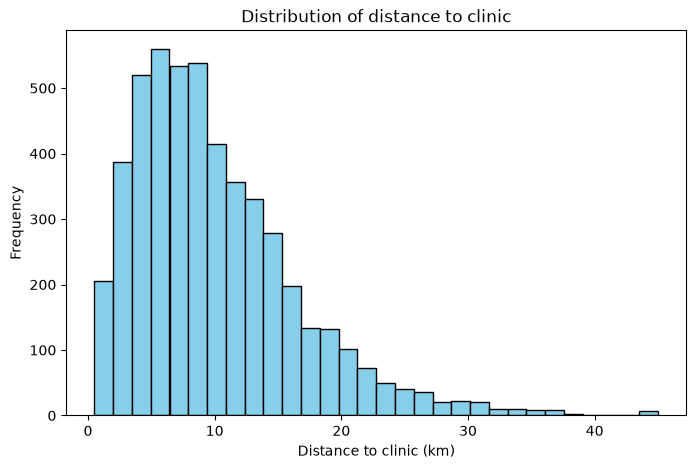

In [125]:
df_working["distance_to_clinic_km"].plot( kind="hist", bins=30, figsize=(8, 5), color= "skyblue",edgecolor= "black")

plt.title("Distribution of distance to clinic")
plt.xlabel("Distance to clinic (km)")
plt.ylabel("Frequency")
plt.show()

#### 5.1.5 Distribution assessment of waiting time

The distribution of waiting_time_minutes is examined to assess its shape, spread, and the presence of potential extreme values.

This assessment will be used together with the descriptive statistics to determine an appropriate strategy for handling the missing values in this variable.

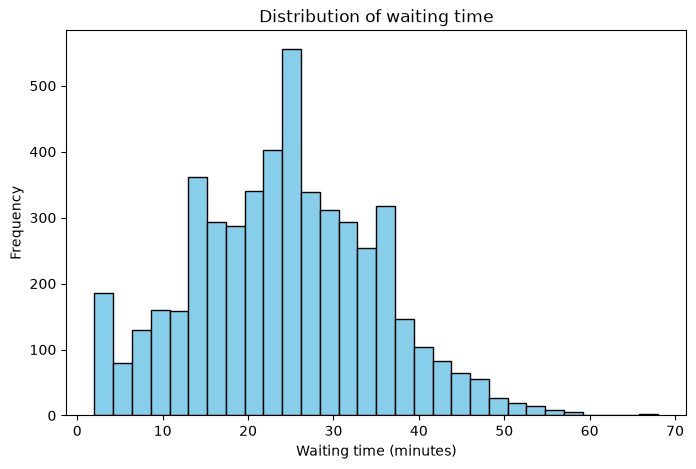

In [127]:
df_working["waiting_time_minutes"].plot( kind="hist", bins=30, figsize=(8, 5), color= "skyblue", edgecolor="black")

plt.title("Distribution of waiting time")
plt.xlabel("Waiting time (minutes)")
plt.ylabel("Frequency")
plt.show()

#### 5.1.6 Imputation strategy

The distributional characteristics of the numerical variables were considered when selecting an approach for the remaining missing values.

The distance_to_clinic_km has a mean of approximately 10.11 km and a median of 8.70 km, with the mean exceeding the median. This indicates some right-skewness and suggests that the median is more appropriate than the mean for imputation because it is less sensitive to extreme values.

The waiting_time_minutes has a mean of approximately 24.19 minutes and a median of 24 minutes. Although the mean and median are very similar, the median will also be used for consistency and robustness to potential extreme observations.

Therefore, the missing values in both numerical variables will be imputed using their respective medians. This approach preserves all 5,000 observations while reducing the influence of potentially extreme values.

#### 5.1.7 Apply numerical imputation

The selected imputation strategy is now applied to the numerical variables containing missing values.

The median of each variable is calculated from the available observations and used to replace its corresponding missing values.

This operation is performed on the working dataset (df_working) rather than the original source file, ensuring that the original project resource remains unchanged.

In [50]:
distance_median = df_working["distance_to_clinic_km"].median()
waiting_median = df_working["waiting_time_minutes"].median()

df_working["distance_to_clinic_km"] =  df_working["distance_to_clinic_km"].fillna(distance_median)
df_working["waiting_time_minutes"] = df_working["waiting_time_minutes"].fillna(waiting_median)

print("Distance median:", distance_median)
print("Waiting median:", waiting_median)



Distance median: 8.7
Waiting median: 24.0


## 5.1.8 Verify missing values after imputation

The numerical imputation is verified by checking the remaining missing values in the affected variables.

The verification confirms whether the previously identified missing observations have been successfully addressed without introducing additional missing values.

In [51]:
df_working[["reminder_channel", "distance_to_clinic_km", "waiting_time_minutes"]].isnull().sum()

reminder_channel         0
distance_to_clinic_km    0
waiting_time_minutes     0
dtype: int64

### 5.2 Duplicate records

Duplicate records are assessed to determine whether the working dataset contains identical appointment records.

Duplicate observations can distort descriptive statistics and may cause the same appointment to be represented more than once during model training.

The duplicate check will be performed before any duplicate records are removed. The results will be documented and evaluated to determine the appropriate treatment.

In [52]:
df_working.duplicated().sum()

np.int64(0)

#### 5.2.1 Duplicate check result

The duplicate record assessment identified 0 exact duplicate rows in the working dataset.

Therefore, no duplicate records need to be removed at this stage. The dataset retains all 5,000 observations for further analysis and modelling preparation.

#### 5.2.2 Identifier integrity & uniqueness

The uniqueness and integrity of the identifier fields are assessed to determine whether each appointment can be uniquely identified.

The appointment_id is expected to be unique because each record represents an individual appointment. In contrast, patient_id is expected to occur multiple times because the same patient may have more than one appointment.

The two identifiers will therefore be assessed separately to distinguish expected repeated patients from potential duplicate appointment records.

#### 5.2.3 Appointment id uniqueness

The uniqueness of appointment_id is assessed to determine whether each appointment record has a unique identifier.

In [53]:
df_working["appointment_id"].nunique()

5000

In [54]:
len(df_working)

5000

#### 5.2.4 Appointment id check result

The dataset contains 5,000 records and 5,000 unique appointment_id values.

This confirms that each appointment record has a unique appointment identifier. No duplicate appointment identifiers were detected, so no changes are required for the appointment_id field.

#### 5.2.5 Patient id repetition assessment

The frequency of patient_id values is examined to determine whether patients have multiple appointments.

Repeated patient identifiers are not automatically considered duplicates because a patient may legitimately attend multiple appointments. The analysis will therefore assess the number of unique patients and the distribution of appointments per patient.

In [55]:
df_working["patient_id"].nunique()

1696

In [56]:
df_working["patient_id"].value_counts().describe()

count    1696.000000
mean        2.948113
std         1.521029
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         9.000000
Name: count, dtype: float64

#### 5.2.6 Patient id check result

The dataset contains 1,696 unique patients across 5,000 appointment records. This indicates that patients may have multiple appointments within the dataset.

The number of appointments per patient ranges from 1 to 9, with an average of approximately 2.95 appointments per patient and a median of 3 appointments.

The repeated patient_id values are therefore considered legitimate repeated appointments rather than duplicate records. No records will be removed based on repeated patient identifiers.

### 5.3 Categorical consistency

Categorical variables are assessed for consistency to identify unexpected categories, spelling variations, inconsistent formatting, or values that may require standardization.

The categorical values will first be inspected without modifying the working dataset. Any required cleaning will only be performed after the identified values have been evaluated.

#### 5.3.1 Inspect categorical values

The unique values and their frequencies are examined for the categorical variables in the working dataset.

This inspection will help identify potential inconsistencies in variables such as gender, age group, appointment type, appointment day, appointment time, reminder status, reminder channel, and appointment outcome.

In [59]:
categorical_columns = df_working.select_dtypes(include= "string").columns

for column in categorical_columns:
    print(f"\n{column}")
    print(df_working[column].value_counts(dropna=False))



appointment_id
appointment_id
HC-00001    1
HC-00002    1
HC-00003    1
HC-00004    1
HC-00005    1
           ..
HC-04996    1
HC-04997    1
HC-04998    1
HC-04999    1
HC-05000    1
Name: count, Length: 5000, dtype: int64

patient_id
patient_id
P-1776    9
P-1742    9
P-1399    9
P-1104    8
P-0780    8
         ..
P-0228    1
P-0050    1
P-0313    1
P-0730    1
P-1262    1
Name: count, Length: 1696, dtype: int64

gender
gender
Female               2488
Male                 2404
Prefer not to say     108
Name: count, dtype: int64

age_group
age_group
65+      1241
35-44     819
55-64     800
45-54     793
25-34     783
18-24     564
Name: count, dtype: int64

appointment_type
appointment_type
General Consultation       2086
Follow-up                  1421
Specialist Consultation     900
Diagnostic Test             593
Name: count, dtype: int64

booking_date
booking_date
8/24/2025     20
2/16/2026     19
1/26/2026     19
2/27/2026     18
11/2/2025     18
              ..
11/12/2024  

#### 5.3.2 Categorical consistency findings

The categorical value inspection did not identify obvious spelling variations, inconsistent capitalization, or unexpected category labels in the main categorical variables.

The gender variable contains Female, Male, and Prefer not to say. The age_group, appointment_type, appointment_day, and appointment_time variables also contain consistent and logically expected categories.

The reminder_sent variable contains Yes and No, while reminder_channel contains SMS, WhatsApp, Email, and No Reminder. The No Reminder category is consistent with the earlier treatment of structurally missing reminder channel values for appointments where no reminder was sent.

The appointment_outcome variable contains three meaningful outcomes: Attended, No-Show, and Cancelled.

No categorical standardization or recoding is required at this stage. The categorical variables can proceed to the subsequent stages of exploratory analysis and model preparation.

### 5.4 Numerical data validation

Numerical variables are assessed to identify invalid, impossible, or potentially problematic values.

The validation focuses on checking whether the observed ranges are logically consistent with the meaning of each variable. This step helps prevent erroneous values from affecting exploratory analysis and subsequent machine learning modelling.

#### 5.4.1 Identify numerical variables

The numerical variables in the working dataset are identified to establish which fields require range and validity checks.

In [61]:
numeric_columns = df_working.select_dtypes(include= ["int64", "float64"]).columns

print(numeric_columns)


Index(['age', 'booking_lead_days', 'previous_appointments',
       'previous_no_shows', 'distance_to_clinic_km', 'waiting_time_minutes'],
      dtype='str')


#### 5.4.2 Range and validity checks

The numerical variables are checked against their expected logical ranges to identify impossible or potentially invalid observations.

The validation focuses on variables where negative values or logically inconsistent relationships could indicate data quality problems. In particular, age, booking_lead_days, previous_appointments, and previous_no_shows should not contain negative values.

In addition, previous_no_shows should not exceed previous_appointments, because a no-show represents a previous appointment that was not attended.

In [62]:
#Checking for every numerical column for negative values
print("Negative values:")
print((df_working[numeric_columns]<0).sum())

Negative values:
age                      0
booking_lead_days        0
previous_appointments    0
previous_no_shows        0
distance_to_clinic_km    0
waiting_time_minutes     0
dtype: int64


In [63]:
invalid_previous_no_shows = (df_working["previous_no_shows"] > df_working["previous_appointments"]).sum()

print("Records where previous_no_shows> previous_appointments:", invalid_previous_no_shows)

Records where previous_no_shows> previous_appointments: 0


#### 5.4.3 Numerical range assessment

The minimum and maximum values of the numerical variables are examined to identify values that may fall outside their expected or plausible ranges.

This assessment provides an additional validation layer after the logical consistency checks and helps identify potential outliers or data entry errors that may require further investigation.

In [65]:
df_working[numeric_columns].agg(["min", "max"]).T  

,min,max
age,18.0,80.0
booking_lead_days,0.0,60.0
previous_appointments,0.0,11.0
previous_no_shows,0.0,5.0
distance_to_clinic_km,0.5,45.0
waiting_time_minutes,2.0,68.0


#### 5.4.4 Numerical range validation findings

The numerical range assessment indicates that all six numerical variables contain values within plausible ranges.

The age variable ranges from 18 to 80 years, while booking_lead_days ranges from 0 to 60 days. The previous_appointments ranges from 0 to 11, and previous_no_shows ranges from 0 to 5.

The distance_to_clinic_km variable ranges from 0.5 to 45 km, while waiting_time_minutes ranges from 2 to 68 minutes.

Together with the previous logical consistency checks, no obvious impossible or invalid numerical values were identified. Therefore, no numerical values require correction based on range validation.

#### 5.4.5 Outlier assessment

Potential outliers in the numerical variables are assessed using the Interquartile Range (IQR) method.

The IQR is calculated as the difference between the third quartile (Q3) and first quartile (Q1). Observations below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR are flagged as potential outliers.

A value identified as a potential outlier is not automatically considered an error. The observations will be evaluated in the context of the corresponding variable before any decision is made to retain, transform, or remove them.

In [67]:
Q1 = df_working[numeric_columns].quantile (0.25)
Q3 = df_working[numeric_columns].quantile(0.75)

IQR = Q3 -Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

outlier_counts = ((df_working[numeric_columns] <lower_bound) | (df_working[numeric_columns] >upper_bound)).sum()

outlier_counts

age                        0
booking_lead_days          0
previous_appointments     64
previous_no_shows         93
distance_to_clinic_km    161
waiting_time_minutes      33
dtype: int64

#### 5.4.6 Outlier assessment findings

The IQR-based assessment identified potential outliers in four numerical variables: previous_appointments (64 observations), previous_no_shows (93 observations), distance_to_clinic_km (161 observations), and waiting_time_minutes (33 observations).

No potential outliers were identified in age or booking_lead_days.

These observations are not automatically classified as errors. The identified values may represent legitimate variation in patient behaviour, distance from the clinic, or waiting times. Further inspection is therefore required before deciding whether any treatment is necessary.

At this stage, no observations are removed or modified based solely on the IQR outlier detection results.

In [68]:
for column in ["previous_appointments", "previous_no_shows", "distance_to_clinic_km", "waiting_time_minutes"]:


    print(f"\n{column}")
    print(df_working[column].describe())           


previous_appointments
count    5000.000000
mean        3.013800
std         1.741211
min         0.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        11.000000
Name: previous_appointments, dtype: float64

previous_no_shows
count    5000.000000
mean        0.544200
std         0.746832
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         5.000000
Name: previous_no_shows, dtype: float64

distance_to_clinic_km
count    5000.000000
mean       10.084200
std         6.533127
min         0.500000
25%         5.300000
50%         8.700000
75%        13.325000
max        45.000000
Name: distance_to_clinic_km, dtype: float64

waiting_time_minutes
count    5000.000000
mean       24.187400
std        10.797815
min         2.000000
25%        17.000000
50%        24.000000
75%        31.000000
max        68.000000
Name: waiting_time_minutes, dtype: float64


#### 5.4.7 Outlier investigation findings

The descriptive statistics indicate that the potential outliers identified by the IQR method fall within plausible ranges for the HealthConnect appointment context.

The previous_appointments ranges from 0 to 11, while previous_no_shows ranges from 0 to 5. These values may represent patients with relatively extensive appointment histories or repeated previous no-shows.

The distance_to_clinic_km ranges from 0.5 to 45 km. Although the upper values are relatively high, they are plausible for patients travelling from locations further away from the clinic.

The waiting_time_minutes ranges from 2 to 68 minutes. Higher waiting times may represent genuine variation in clinic waiting periods rather than data-entry errors.

Based on this assessment, the identified statistical outliers are considered potentially legitimate observations rather than confirmed data-quality errors. Therefore, no observations will be removed or modified based solely on the IQR method.

#### 5.4.8 Numerical validation conclusion

The numerical validation identified no negative values, no violations of the logical relationship between previous_no_shows and previous_appointments, and no values outside the plausible ranges established for the dataset.

Although the IQR method identified potential outliers in four variables, further assessment indicated that these observations fall within plausible values for the healthcare appointment context.

No numerical observations will therefore be removed or modified as part of the numerical data validation process.

### 5.5 Potential data quality issues

The data quality assessment identified several areas requiring attention before the dataset can be used for exploratory analysis and machine learning modelling.

Missing values were identified in reminder_channel, distance_to_clinic_km, and waiting_time_minutes. The missing values in reminder_channel were determined to be structural because they occurred when no reminder was sent, and were therefore represented as No Reminder. Missing numerical values in distance_to_clinic_km and waiting_time_minutes were addressed using median imputation.

No exact duplicate records were identified. The appointment_id field was confirmed to contain 5,000 unique identifiers for 5,000 records, while repeated patient_id values were considered legitimate because patients can have multiple appointments.

The categorical variables were inspected and no obvious spelling, capitalization, or unexpected category inconsistencies were identified.

Numerical validation identified no negative values and no logical violations between previous_no_shows and previous_appointments. The IQR method identified potential statistical outliers in some numerical variables; however, further assessment indicated that these values were plausible within the healthcare appointment context. Therefore, they were retained rather than removed.

The original project resources were not overwritten. All data quality operations were performed on the working copy, df_working, to preserve the original dataset for reproducibility and future reference.

#### 5.5.1 Final data quality status

Following the data quality assessment and appropriate treatment of identified issues, the working dataset is considered suitable for the next stage of the project.

The final working dataset contains 5,000 appointment records and 18 variables. No observations were removed due to duplication or statistical outliers.

The dataset is now ready to proceed to the next stage of the Week 5 baseline modelling workflow.

## 6. Target variable preparation

The target variable represents the outcome of an appointment and will be prepared for binary classification.

The original appointment_outcome variable contains three categories: Attended, No-Show, and Cancelled. Before encoding the target, the distribution of these outcomes will be examined to understand the class structure and determine how cancelled appointments should be treated.

### 6.1 Appointment outcome distribution

The distribution of appointment outcomes is examined to determine the frequency of each outcome category before preparing the binary target variable.

In [69]:
df_working["appointment_outcome"].value_counts()

appointment_outcome
No-Show      2423
Attended     2314
Cancelled     263
Name: count, dtype: int64

#### 6.1.1 Distribution findings

The appointment outcome distribution shows three categories across the 5,000 appointment records.

There are 2,423 No-Show appointments, 2,314 Attended appointments, and 263 Cancelled appointments. No-Show appointments therefore represent the largest outcome category, followed closely by Attended appointments, while Cancelled appointments account for a relatively small proportion of the dataset.

Because the objective of the baseline model is to predict appointment no-shows, the treatment of Cancelled appointments must be determined before creating the binary target variable.

### 6.2 Treatment of cancelled appointments

The appointment_outcome variable contains three outcomes: Attended, No-Show, and Cancelled.

Since the baseline modelling objective is to predict whether an appointment will result in a no-show, cancelled appointments do not directly represent either of the two target classes. Their treatment must therefore be considered carefully to avoid introducing noise or an incorrect target definition.

For the baseline classification task, cancelled appointments will be excluded from the modelling dataset because they do not represent either an attended appointment or a no-show.

In [71]:
df_model= df_working[ df_working["appointment_outcome"].isin( ["Attended", "No-Show"])].copy()

In [72]:
df_model["appointment_outcome"].value_counts()

appointment_outcome
No-Show     2423
Attended    2314
Name: count, dtype: int64

### 6.3 Binary target encoding

For binary classification, the appointment_outcome variable is converted from categorical labels into a binary numerical target.

No-Show will be encoded as 1, representing the positive class of interest, while Attended will be encoded as 0.
|
A new target variable will be created rather than overwriting the original appointment_outcome column. This preserves the original outcome labels for interpretation and validation.

#### 6.3.1 Create the binary target

A new no_show target variable is created from appointment_outcome. The target takes the value 1 when an appointment is a No-Show and 0 when an appointment is Attended.

In [75]:
df_model["no_show"] = (df_model["appointment_outcome"] == "No-Show").astype(int)

#### 6.3.2 Verify binary target

In [76]:
df_model["no_show"].value_counts()

no_show
1    2423
0    2314
Name: count, dtype: int64

In [77]:
df_model["no_show"].value_counts(normalize = True)*100

no_show
1    51.150517
0    48.849483
Name: proportion, dtype: float64

#### 6.3.3 Binary target distribution findings

The binary target variable is relatively well balanced. No-Show appointments account for 51.15% of the modelling dataset, while Attended appointments account for 48.85%.

The difference between the two classes is small, indicating that there is no severe class imbalance that would require corrective techniques such as oversampling or undersampling at this stage.

The binary target is therefore considered suitable for baseline classification modelling.

## 7. Data leakage assessment

The dataset is assessed for potential data leakage before model development. Data leakage occurs when information that would not be available at prediction time is used as a model feature.

The objective is to ensure that the baseline model learns from information that could realistically be available when predicting whether an appointment will result in a no-show.

### 7.1 Potential leakage variables

Potential data leakage variables are identified by considering whether their information would be available at the time an appointment no-show prediction needs to be made.

Variables that directly describe the appointment outcome or information that becomes known only after the appointment may introduce target leakage and should not be used as predictive features.

The main variables requiring consideration are appointment_outcome, waiting_time_minutes, and potentially other variables whose availability depends on events occurring close to or after the appointment.

#### 7.1.1 Appointment outcome

The appointment_outcome variable is identified as a direct source of target leakage because it contains the actual outcome of the appointment.

The binary target no_show was created directly from this variable. Including appointment_outcome as a predictor would therefore provide the model with information equivalent to the target it is expected to predict.

Consequently, appointment_outcome will be excluded from the predictive features.

### 7.2 Prediction time availability

For each potential predictor, its availability at the intended prediction time must be considered.

The baseline model is intended to predict the likelihood of a patient missing an appointment before the appointment takes place. Therefore, predictor variables should represent information that would reasonably be available before or at the time the prediction is made.

Variables that are only known after the appointment or are generated as a result of the appointment should not be used as predictive features.

#### 7.2.1 Waiting time availability

The waiting_time_minutes variable requires careful consideration because actual waiting time would only be known after the patient arrives at the clinic.

Since the modelling objective is to predict a potential no-show before the appointment occurs, the actual waiting time would not be available at prediction time.

Using this variable as a predictor could therefore introduce data leakage by providing information generated after the patient has already arrived.

Consequently, waiting_time_minutes will be excluded from the baseline model features.

### 7.3 Leakage decision

The identified variables are assessed according to their availability at the intended prediction time. The baseline model is designed to predict whether an appointment will result in a no-show before the appointment takes place.

Variables that directly contain the appointment outcome or information generated after the patient arrives at the clinic are excluded from the baseline predictive features. Variables representing information that would normally be known before the appointment are retained as candidate predictors.

The following variables will therefore be excluded from the baseline model:

- appointment_outcome — directly represents the appointment outcome and is the source of the target variable.
- waiting_time_minutes — represents information that would only be known after the patient arrives at the clinic.

The remaining variables will be considered as candidate predictors, subject to further feature preparation and validation.

#### 7.3.1 Baseline feature eligibility

In [81]:
candidate_features = ["gender", "age","age_group","appointment_type",
                      "booking_date", "appointment_date","appointment_day",
                      "appointment_time","booking_lead_days","previous_appointments",
                      "previous_no_shows","reminder_sent","reminder_channel","distance_to_clinic_km"]

excluded_features = ["appointment_outcome","waiting_time_minutes"]

print("Candidate features:")
print(candidate_features)

print("\nExcluded features:")
print(excluded_features)

Candidate features:
['gender', 'age', 'age_group', 'appointment_type', 'booking_date', 'appointment_date', 'appointment_day', 'appointment_time', 'booking_lead_days', 'previous_appointments', 'previous_no_shows', 'reminder_sent', 'reminder_channel', 'distance_to_clinic_km']

Excluded features:
['appointment_outcome', 'waiting_time_minutes']


#### 7.3.2 Reminder variable timing

The reminder-related variables require additional consideration because their availability depends on when the prediction is made.

The reminder_sent indicates whether a reminder was sent, while reminder_channel indicates the channel used when a reminder was sent. If these variables are recorded after the prediction point, using them could introduce temporal leakage.

Their inclusion will therefore depend on whether the reminder information would be available before the appointment no-show prediction is generated.

#### 7.3.3 Prediction time definition

For the baseline model, the prediction is assumed to be generated before the scheduled appointment takes place, using information available during the pre-appointment period.

Under this definition, reminder information may be available before the appointment. However, the timing of reminder_sent and reminder_channel must be considered carefully because these variables may depend on the healthcare facility's reminder process.

The baseline model will retain these variables as candidate predictors only if their values represent information that would be available at the defined prediction point.

In [82]:
df_model[["booking_date", "appointment_date", "reminder_sent", "reminder_channel"]].head(10)

,booking_date,appointment_date,reminder_sent,reminder_channel
0,2/6/2025,2/18/2025,Yes,WhatsApp
1,2/25/2026,2/27/2026,Yes,SMS
2,11/16/2025,12/24/2025,Yes,SMS
3,7/18/2025,8/28/2025,Yes,SMS
4,7/9/2025,8/25/2025,Yes,Email
5,2/16/2026,4/14/2026,No,No Reminder
6,1/17/2025,2/16/2025,Yes,WhatsApp
7,11/27/2025,1/16/2026,Yes,SMS
8,3/9/2025,4/21/2025,Yes,SMS
9,2/5/2025,2/21/2025,Yes,SMS


#### 7.3.4 Reminder variable leakage decision

The reminder variables were investigated by comparing the booking dates, appointment dates, and reminder information.

The records show that reminders are associated with appointments before their scheduled appointment dates. However, the dataset does not provide the exact date or time at which each reminder was sent. Therefore, it cannot be established with certainty whether the reminder information would have been available at the exact prediction point.

To maintain a conservative and reproducible baseline modelling approach, reminder_sent and reminder_channel will be excluded from the baseline predictive features. This prevents the model from relying on information whose prediction-time availability cannot be conclusively established.

The variables are retained in the working dataset for potential future analysis but will not be used as baseline model predictors.

In [83]:
candidate_features = ["gender","age","age_group","appointment_type",
                      "booking_date","appointment_date","appointment_day",
                      "appointment_time","booking_lead_days", "previous_appointments",
                      "previous_no_shows","distance_to_clinic_km"]

excluded_features = ["appointment_outcome","waiting_time_minutes","reminder_sent","reminder_channel"]

print("Candidate features:")
print(candidate_features)

print("\nExcluded features:")
print(excluded_features)

Candidate features:
['gender', 'age', 'age_group', 'appointment_type', 'booking_date', 'appointment_date', 'appointment_day', 'appointment_time', 'booking_lead_days', 'previous_appointments', 'previous_no_shows', 'distance_to_clinic_km']

Excluded features:
['appointment_outcome', 'waiting_time_minutes', 'reminder_sent', 'reminder_channel']


#### 7.3.5 Final leakage assessment

The data leakage assessment identified four variables that will be excluded from the baseline model.

The appointment_outcome is excluded because it directly represents the appointment outcome and was used to create the target variable. 
The waiting_time_minutes is excluded because the actual waiting time would only be known after the patient arrives at the clinic. 
The reminder_sent and reminder_channel are excluded because the dataset does not provide the exact timing of the reminder, making their availability at the prediction point uncertain.

The remaining candidate variables represent information that can reasonably be available during the pre-appointment period and will be considered for baseline modelling.

The original and working datasets remain unchanged by this feature eligibility assessment. Variables are only being classified as eligible or excluded; actual feature selection and transformation will be performed in the next stage.

## 8. Data preparation

### 8.1 Handling missing values

In [85]:
df_model.isnull().sum()

appointment_id           0
patient_id               0
gender                   0
age                      0
age_group                0
appointment_type         0
booking_date             0
appointment_date         0
appointment_day          0
appointment_time         0
booking_lead_days        0
previous_appointments    0
previous_no_shows        0
reminder_sent            0
reminder_channel         0
distance_to_clinic_km    0
waiting_time_minutes     0
appointment_outcome      0
no-show                  0
no_show                  0
dtype: int64

#### 8.1.1 Missing value verification

In [86]:
df_model.columns.tolist()

['appointment_id',
 'patient_id',
 'gender',
 'age',
 'age_group',
 'appointment_type',
 'booking_date',
 'appointment_date',
 'appointment_day',
 'appointment_time',
 'booking_lead_days',
 'previous_appointments',
 'previous_no_shows',
 'reminder_sent',
 'reminder_channel',
 'distance_to_clinic_km',
 'waiting_time_minutes',
 'appointment_outcome',
 'no-show',
 'no_show']

#### 8.1.2 Inspect duplicate target like variables

In [88]:
df_model["no-show"].value_counts(dropna=False)

no-show
1    2423
0    2314
Name: count, dtype: int64

In [89]:
df_model[["no-show", "no_show"]].head(10)

,no-show,no_show
0,1,1
1,0,0
2,1,1
3,0,0
4,1,1
5,1,1
6,1,1
7,0,0
8,1,1
9,0,0


#### 8.1.3 Remove duplicate target variable

The dataset contains two target-like variables, no-show and no_show. Inspection confirms that both columns contain identical binary values.

The no_show variable was intentionally created as the binary target during target preparation. Therefore, the duplicate no-show variable is unnecessary and will be removed from the modelling dataset.

The original df_working dataset will not be modified.

In [90]:
df_model = df_model.drop(columns= ["no-show"])

In [91]:
df_model.columns.tolist()

['appointment_id',
 'patient_id',
 'gender',
 'age',
 'age_group',
 'appointment_type',
 'booking_date',
 'appointment_date',
 'appointment_day',
 'appointment_time',
 'booking_lead_days',
 'previous_appointments',
 'previous_no_shows',
 'reminder_sent',
 'reminder_channel',
 'distance_to_clinic_km',
 'waiting_time_minutes',
 'appointment_outcome',
 'no_show']

In [92]:
df_model.isnull().sum().sum()

np.int64(0)

### 8.2 Handling categorical variables

#### 8.2.1 Identify categorical features

In [95]:
categorical_features = df_model[candidate_features].select_dtypes(include= "string").columns.tolist()

categorical_features

['gender',
 'age_group',
 'appointment_type',
 'booking_date',
 'appointment_date',
 'appointment_day',
 'appointment_time']

#### 8.2.2 Separate categorical and date features

The initial inspection identified seven string-type candidate features. However, booking_date and appointment_date represent calendar dates rather than conventional categorical variables.

These date variables will therefore be treated separately from the nominal categorical variables. The remaining categorical features will be prepared for encoding, while the date variables will be considered for appropriate date-based feature representation during feature engineering.

The categorical features identified for encoding are:

- gender
- age_group
- appointment_type
- appointment_day
- appointment_time

The date features requiring separate treatment are:

- booking_date
- appointment_date

In [96]:
categorical_features = ["gender","age_group","appointment_type","appointment_day","appointment_time"]

date_features = ["booking_date","appointment_date"]

print("Categorical features:")
print(categorical_features)

print("\nDate features:")
print(date_features)

Categorical features:
['gender', 'age_group', 'appointment_type', 'appointment_day', 'appointment_time']

Date features:
['booking_date', 'appointment_date']


#### 8.2.3 Review categorical feature values

In [98]:
for col in categorical_features:
    
    print(f"\n{col}:")
    print(df_model[col].value_counts())


gender:
gender
Female               2358
Male                 2274
Prefer not to say     105
Name: count, dtype: int64

age_group:
age_group
65+      1165
35-44     770
55-64     766
25-34     750
45-54     746
18-24     540
Name: count, dtype: int64

appointment_type:
appointment_type
General Consultation       1980
Follow-up                  1344
Specialist Consultation     846
Diagnostic Test             567
Name: count, dtype: int64

appointment_day:
appointment_day
Sunday       704
Friday       696
Wednesday    693
Saturday     683
Tuesday      662
Monday       655
Thursday     644
Name: count, dtype: int64

appointment_time:
appointment_time
Morning      2116
Afternoon    1979
Evening       642
Name: count, dtype: int64


#### 8.2.4 Categorical feature consistency findings

The categorical feature review shows that all five selected categorical variables contain consistent and meaningful categories.

The gender contains three categories, age_group contains six age bands, appointment_type contains four appointment types, appointment_day contains all seven days of the week, and appointment_time contains three time periods.

No unexpected or inconsistent categorical values were identified. These variables are therefore suitable for categorical encoding during the modelling preparation stage.

#### 8.2.5 Categorical encoding strategy

Categorical variables will be converted into numerical representations during model preprocessing. One-hot encoding will be used for the nominal categorical variables because their categories do not have an inherent numerical order.

This approach will create separate binary indicator variables for the categories within each categorical feature while avoiding the introduction of artificial numerical relationships between categories.

The encoding will be performed as part of the modelling preprocessing workflow rather than manually replacing values in the original dataset.

### 8.3 Handling numerical variables

#### 8.3.1 Identify numerical features

In [102]:
numerical_features = df_model[candidate_features].select_dtypes(include=["int64", "float64"]).columns.tolist()
                                                                         
numerical_features

['age',
 'booking_lead_days',
 'previous_appointments',
 'previous_no_shows',
 'distance_to_clinic_km']

#### 8.3.2 Numerical feature review

The numerical feature review identified five numerical candidate predictors: age, booking_lead_days, previous_appointments, previous_no_shows, and distance_to_clinic_km.

These variables represent patient characteristics, appointment booking behaviour, previous appointment history, and physical distance from the clinic. Their values have already been checked for missing values and basic numerical validity during the data quality assessment.

No numerical variables require immediate removal based on their data types or observed ranges. However, scaling and any additional transformations will be performed later within the modelling preprocessing workflow, after the train/test split.

#### 8.3.3 Numerical scaling strategy

Numerical features will not be manually scaled at this stage. Scaling will be performed later as part of the model preprocessing pipeline, using parameters learned from the training data only.

This approach prevents information from the test set from influencing the preprocessing stage and ensures that the final modelling workflow is reproducible and suitable for evaluating model performance.

### 8.4 Removing excluded variables

#### 8.4.1 Define excluded variables

In [105]:
excluded_features

['appointment_outcome',
 'waiting_time_minutes',
 'reminder_sent',
 'reminder_channel']

#### Excluded variables

The following variables were excluded from the baseline modelling dataset based on the data leakage assessment:

- appointment_outcome — directly represents the original appointment outcome.
- waiting_time_minutes — represents information that would only be available after the patient arrives.
- reminder_sent — the exact timing of the reminder is unavailable.
- reminder_channel — the exact timing of the reminder is unavailable.

These variables will not be used as baseline model predictors.

#### 8.4.2 Create prepared dataset

In [106]:
df_prepared = df_model.drop(columns=excluded_features)

In [107]:
df_prepared.columns.tolist()

['appointment_id',
 'patient_id',
 'gender',
 'age',
 'age_group',
 'appointment_type',
 'booking_date',
 'appointment_date',
 'appointment_day',
 'appointment_time',
 'booking_lead_days',
 'previous_appointments',
 'previous_no_shows',
 'distance_to_clinic_km',
 'no_show']

In [108]:
df_prepared.shape

(4737, 15)

#### 8.4.3 Remove identifier variables

In [110]:
identifier_features = ["appointment_id", "patient_id"]

df_prepared = df_prepared.drop(columns=identifier_features)

In [111]:
df_prepared.shape

(4737, 13)

In [112]:
df_prepared.columns.tolist()

['gender',
 'age',
 'age_group',
 'appointment_type',
 'booking_date',
 'appointment_date',
 'appointment_day',
 'appointment_time',
 'booking_lead_days',
 'previous_appointments',
 'previous_no_shows',
 'distance_to_clinic_km',
 'no_show']

#### 8.4.4 Exclusion verification

The prepared dataset no longer contains the identifier variables or the variables excluded during the data leakage assessment.

The remaining columns consist of candidate predictors and the binary target variable no_show. This ensures that the prepared dataset is suitable for the next stage of exploratory analysis and subsequent modelling preparation.

### 8.5 Prepared dataset

#### 8.5.1 Prepared dataset verification

In [113]:
df_prepared.shape

(4737, 13)

In [114]:
df_prepared.isnull().sum().sum()

np.int64(0)

#### 8.5.2 Data preparation summary

The data preparation process resulted in a modelling-ready dataset containing 4,737 appointment records and 13 columns.

The dataset contains five categorical features, two date features, five numerical features, and the binary target variable no_show. Identifier variables and variables excluded during the data leakage assessment were removed.

The prepared dataset contains no missing values. Categorical and numerical variables have been identified but have not yet been encoded or scaled. These transformations will be performed later within the modelling preprocessing workflow.

## 9. Exploratory data analysis

### 9.1 Target distribution

#### 9.1.1 Target class counts

In [116]:
df_prepared["no_show"].value_counts()

no_show
1    2423
0    2314
Name: count, dtype: int64

#### 9.1.2 Target class proportions

In [117]:
df_prepared["no_show"].value_counts(normalize= True)*100

no_show
1    51.150517
0    48.849483
Name: proportion, dtype: float64

#### 9.1.3 Target distribution interpretation

The prepared dataset contains 2,423 no-show appointments (51.15%) and 2,314 attended appointments (48.85%).

The target classes are relatively balanced, with no-show appointments representing only a slightly larger proportion of the dataset. Therefore, severe class imbalance is not present, and no resampling technique is required for the baseline analysis at this stage.

The relatively balanced target distribution also allows standard classification evaluation metrics such as accuracy, precision, recall, F1-score, and ROC-AUC to be interpreted without the strong imbalance concerns that would arise from a highly skewed target.

#### 9.1.4 Target distribution visualization

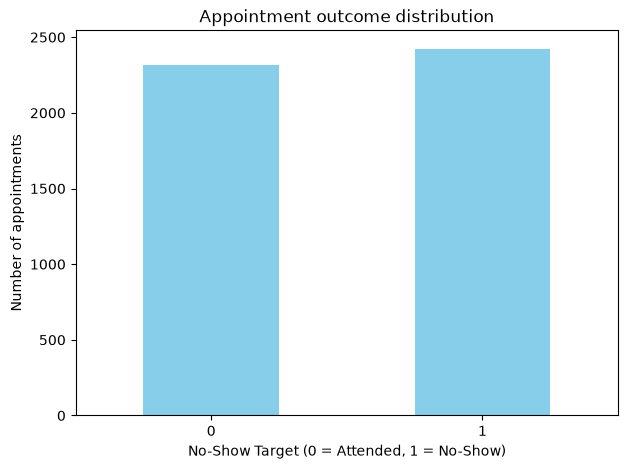

In [120]:
df_prepared["no_show"].value_counts().sort_index().plot(kind= "bar", figsize=(7, 5), color="skyblue")

plt.title("Appointment outcome distribution")
plt.xlabel("No-Show Target (0 = Attended, 1 = No-Show)")
plt.ylabel("Number of appointments")
plt.xticks(rotation=0)
plt.show()

### 9.2 Numerical feature analysis

#### 9.2.1 Numerical summary

In [121]:
df_prepared[numerical_features].describe()

,age,booking_lead_days,previous_appointments,previous_no_shows,distance_to_clinic_km
count,4737.000000,4737.000000,4737.000000,4737.000000,4737.000000
mean,48.719443,29.639012,3.023433,0.551193,10.083872
std,18.147296,17.412842,1.744586,0.750821,6.556556
min,18.000000,0.000000,0.000000,0.000000,0.500000
25%,33.000000,15.000000,2.000000,0.000000,5.300000
50%,49.000000,30.000000,3.000000,0.000000,8.700000
75%,64.000000,45.000000,4.000000,1.000000,13.300000
max,80.000000,60.000000,11.000000,5.000000,45.000000


#### 9.2.2 Numerical summary findings

The numerical summary shows that the dataset contains 4,737 complete appointment records. Patient age ranges from 18 to 80 years, with a mean of 48.72 years and a median of 49 years.

Appointments have an average booking lead time of approximately 30 days, ranging from same day bookings to bookings made 60 days in advance. Patients have an average of approximately three previous appointments.

Previous no-shows have a median of zero and a mean of 0.55, indicating that most patients have no previous no-show history, while a smaller proportion have multiple previous no-shows.

The average distance to the clinic is approximately 10.08 km, with values ranging from 0.5 km to 45 km. The relatively high maximum compared with the median suggests that the distance variable may be right-skewed.

Further distributional patterns will be examined using histograms and boxplots.

#### 9.2.3 Numerical feature histograms

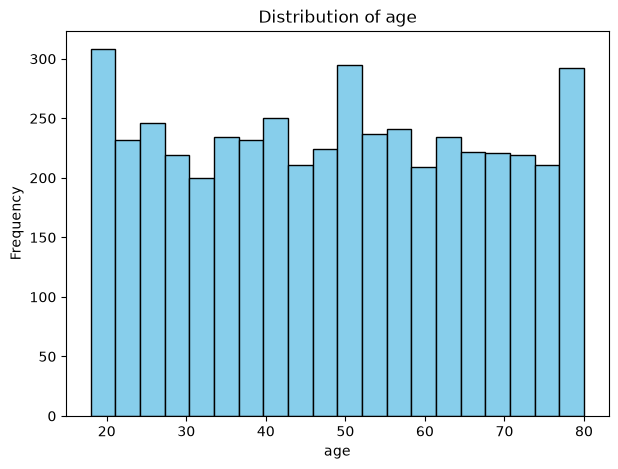

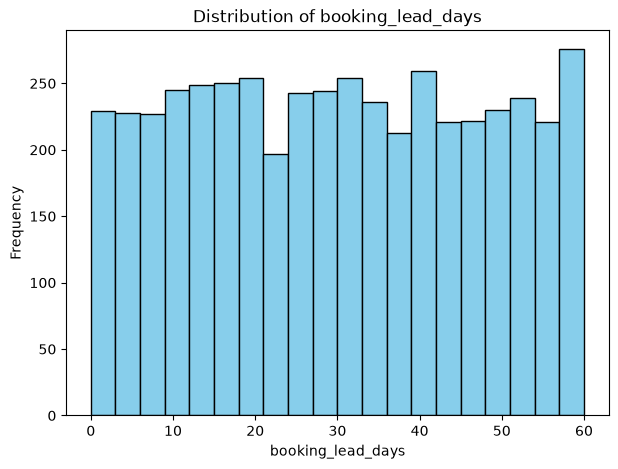

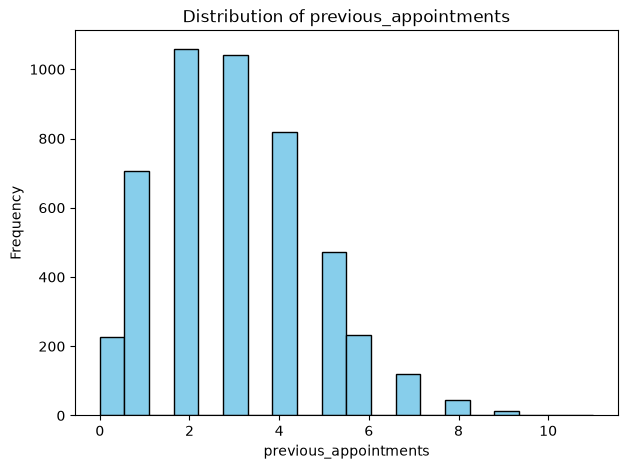

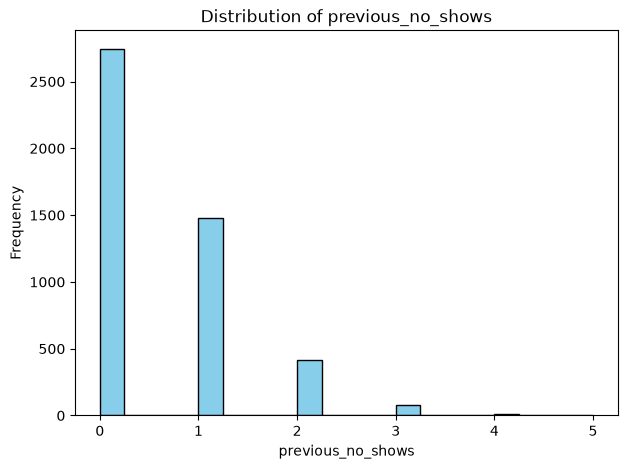

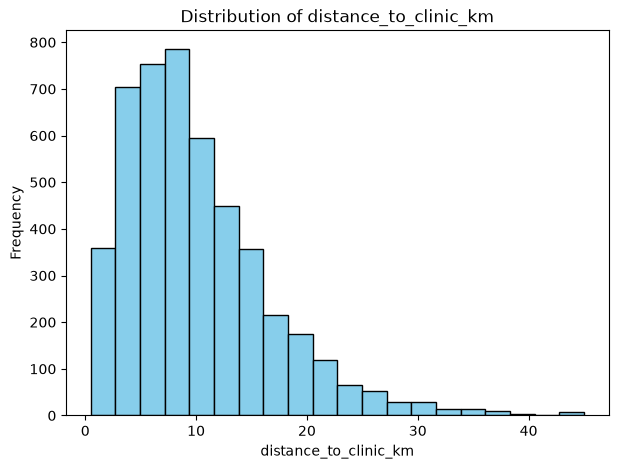

In [124]:
for col in numerical_features:

    plt.figure(figsize=(7, 5))
    plt.hist(df_prepared[col], bins=20, color="skyblue", edgecolor= "black")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

#### 9.2.4 Histogram findings

The histograms show different distributional patterns across the numerical features. Age is relatively centred, with the mean and median being almost identical. Booking lead time is also broadly centred around 30 days.

Previous appointments show some right-skewness, with most observations concentrated at lower values and fewer patients having a larger number of previous appointments. Previous no-shows are strongly concentrated at zero, indicating that most patients have no previous no-show history.

Distance to the clinic shows a right-skewed distribution, with most patients living relatively close to the clinic and a smaller number of patients travelling substantially farther distances.

These distributional patterns will be considered when interpreting the model and when assessing whether any transformations are appropriate.

#### 9.2.5 Numerical feature boxplots

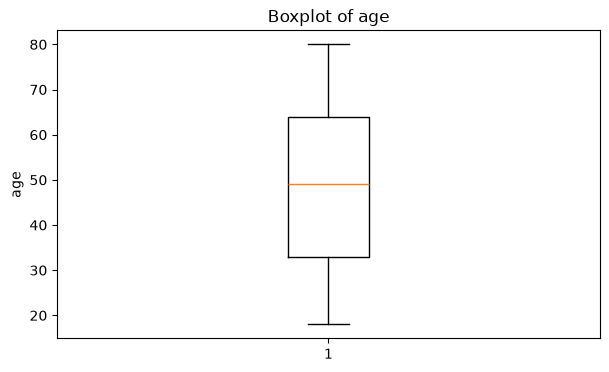

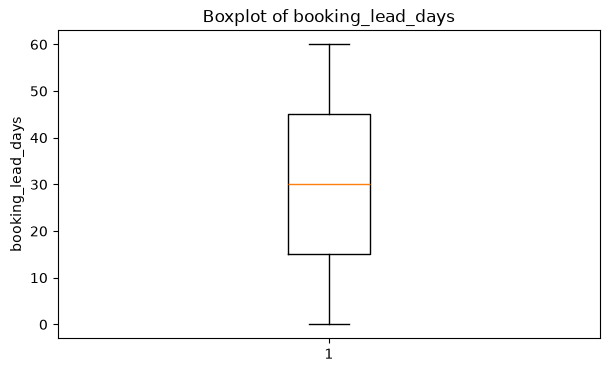

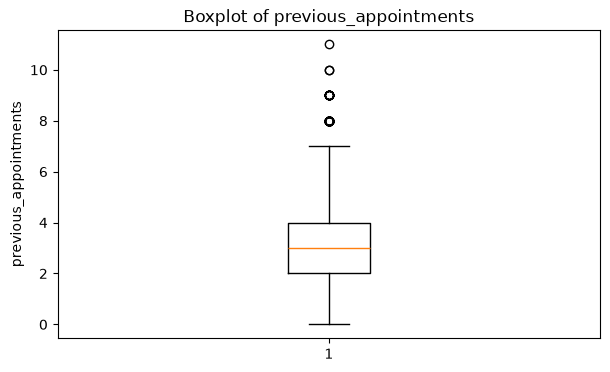

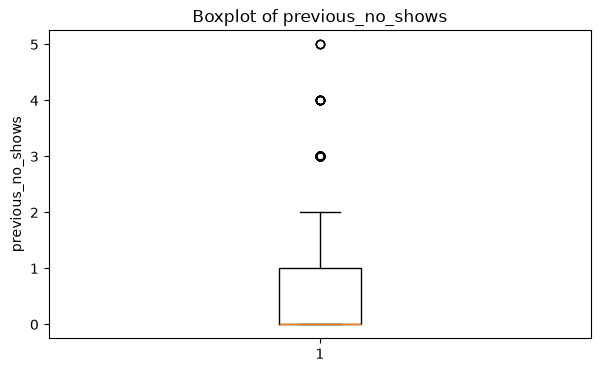

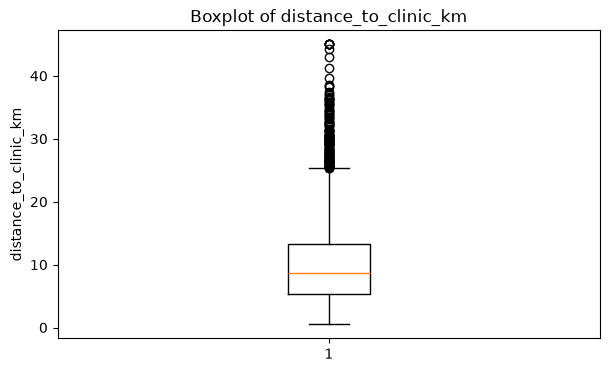

In [130]:
for col in numerical_features:

    plt.figure(figsize=(7, 4))
    plt.boxplot(df_prepared[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

#### 9.2.6 Outlier assessment

The boxplots indicate the presence of potential outliers in some numerical variables. These observations fall beyond the standard boxplot whiskers and therefore differ substantially from the central distribution of the respective variables.

However, the presence of a statistical outlier does not necessarily indicate a data entry error. The observed ranges are plausible within the context of appointment records. For example, a patient may legitimately live a relatively long distance from the clinic or have a higher number of previous appointments.

Therefore, no observations will be removed solely on the basis of the boxplot results. The potential outliers will be retained unless further investigation identifies evidence that they are erroneous or invalid.

This approach preserves potentially meaningful information that could contribute to predicting appointment no-shows.

In [131]:
for col in numerical_features:
    
    Q1 = df_prepared[col].quantile(0.25)
    Q3 = df_prepared[col].quantile(0.75)
    
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 *IQR
    upper_bound = Q3 + 1.5 *IQR

    outliers = df_prepared[(df_prepared[col] < lower_bound) |(df_prepared[col] > upper_bound)]

    print(f"{col}: {len(outliers)} potential outliers")

age: 0 potential outliers
booking_lead_days: 0 potential outliers
previous_appointments: 61 potential outliers
previous_no_shows: 91 potential outliers
distance_to_clinic_km: 151 potential outliers


#### 9.2.6 Outlier assessment findings

The IQR-based assessment identified no potential outliers in age or booking_lead_days. Potential outliers were identified in previous_appointments (61 observations), previous_no_shows (91 observations), and distance_to_clinic_km (151 observations).

These observations were not automatically removed because their values fall within plausible ranges for the healthcare appointment context. For example, patients may legitimately have a higher number of previous appointments or previous no-shows, while some patients may live substantially farther from the clinic.

Therefore, the identified observations will be retained in the dataset. This prevents the removal of potentially meaningful information that may contribute to predicting appointment no-shows.

### 9.3 Categorical feature analysis

#### 9.3.1 Gender distribution

In [134]:
df_prepared["gender"].value_counts()

gender
Female               2358
Male                 2274
Prefer not to say     105
Name: count, dtype: int64

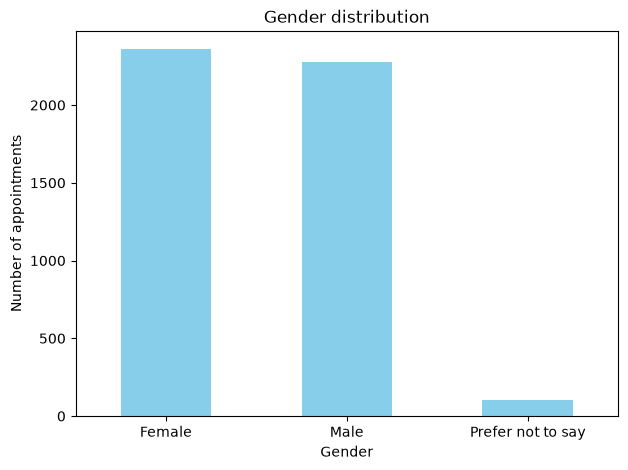

In [135]:
df_prepared["gender"].value_counts().plot(kind="bar",figsize=(7, 5),color="skyblue")

plt.title("Gender distribution")
plt.xlabel("Gender")
plt.ylabel("Number of appointments")
plt.xticks(rotation=0)
plt.show()

In [ ]:
#### 9.3.2 Age group distribution

In [137]:
df_prepared["age_group"].value_counts()

age_group
65+      1165
35-44     770
55-64     766
25-34     750
45-54     746
18-24     540
Name: count, dtype: int64

The age group distribution shows that patients aged 65+ account for the largest number of appointments, with 1,165 appointments. The 35–44 and 55–64 age groups have 770 and 766 appointments, respectively, while the 25–34 and 45–54 groups have similar counts of 750 and 746. The 18–24 age group has the fewest appointments, with 540.

Overall, the dataset contains appointments across all defined age groups, although older patients, particularly those aged 65+, are more strongly represented than younger patients.

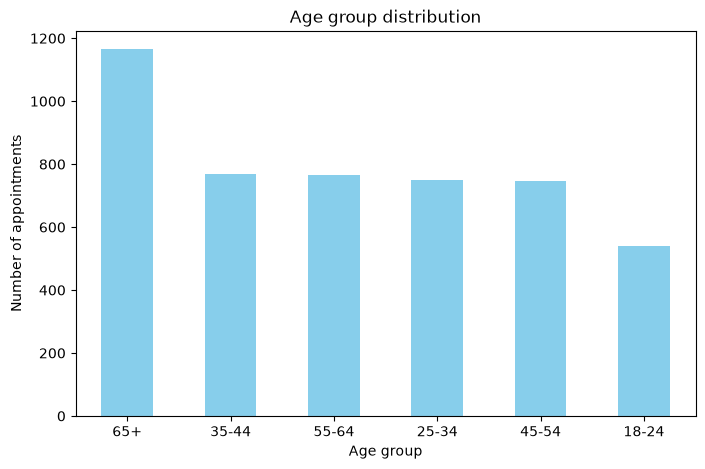

In [138]:
df_prepared["age_group"].value_counts().plot(kind="bar",figsize=(8, 5), color="skyblue")

plt.title("Age group distribution")
plt.xlabel("Age group")
plt.ylabel("Number of appointments")
plt.xticks(rotation=0)
plt.show()

#### 9.3.3 Appointment type distribution

In [139]:
df_prepared["appointment_type"].value_counts()

appointment_type
General Consultation       1980
Follow-up                  1344
Specialist Consultation     846
Diagnostic Test             567
Name: count, dtype: int64

The appointment type distribution shows that General Consultation is the most common appointment type, with 1,980 appointments. Follow-up appointments are the second most common, with 1,344 appointments, followed by Specialist Consultation with 846 appointments. Diagnostic Tests are the least common, with 567 appointments.

Overall, General Consultations account for the largest proportion of appointments in the dataset, while Diagnostic Tests represent a smaller proportion. This variation in appointment type provides an important categorical feature to investigate further when examining its relationship with appointment attendance.

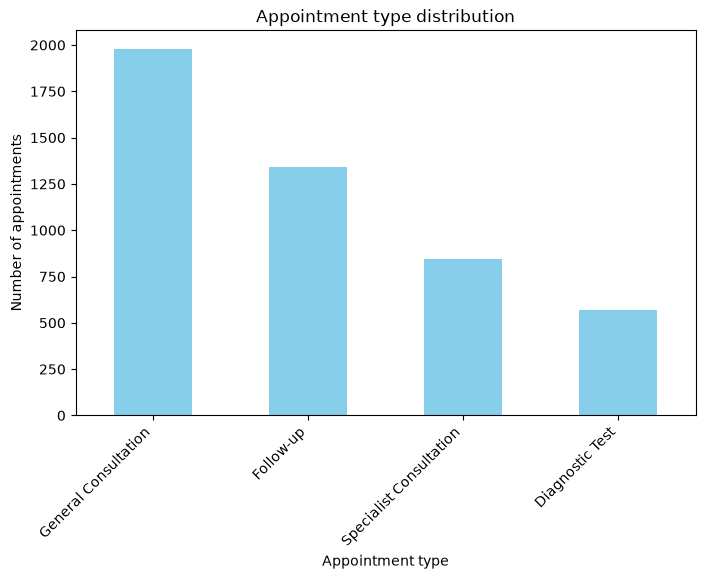

In [140]:
df_prepared["appointment_type"].value_counts().plot(kind="bar",figsize=(8, 5), color="skyblue")

plt.title("Appointment type distribution")
plt.xlabel("Appointment type")
plt.ylabel("Number of appointments")
plt.xticks(rotation=45, ha="right")
plt.show()

### 9.3.4 Appointment day distribution

The appointment day is analysed to understand how appointments are distributed across the different days of the week. Examining this distribution helps identify whether certain days have substantially more appointments than others.

Understanding the appointment scheduling pattern is also important because appointment day may potentially influence patient attendance and no-show behaviour. Therefore, this feature will be examined further in relation to the target variable.

In [141]:
df_prepared["appointment_day"].value_counts()

appointment_day
Sunday       704
Friday       696
Wednesday    693
Saturday     683
Tuesday      662
Monday       655
Thursday     644
Name: count, dtype: int64

The appointment day distribution shows that appointments are relatively evenly distributed across the seven days of the week. Sunday has the highest number of appointments, with 704 appointments, followed by Friday with 696 and Wednesday with 693. Saturday accounts for 683 appointments, while Tuesday and Monday have 662 and 655 appointments, respectively. Thursday has the lowest number of appointments, with 644 appointments.

The difference between the highest and lowest appointment counts is relatively small, suggesting that appointments are not concentrated on a particular day of the week. All seven days are sufficiently represented in the dataset, making appointment day a useful categorical feature to investigate further in relation to patient no-show behaviour.

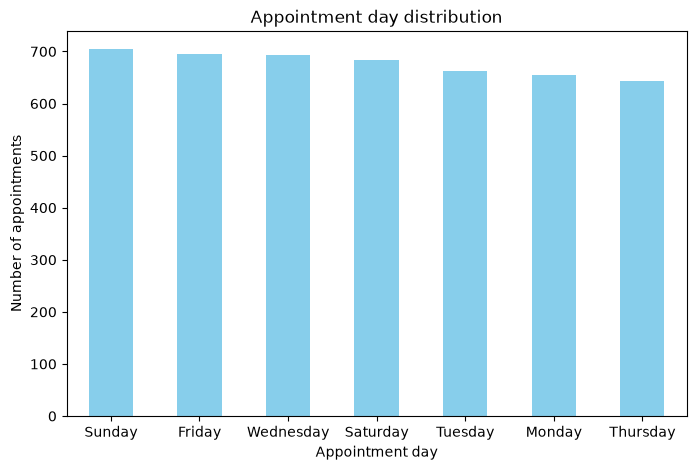

In [142]:
df_prepared["appointment_day"].value_counts().plot(kind="bar",figsize=(8, 5), color="skyblue")

plt.title("Appointment day distribution")
plt.xlabel("Appointment day")
plt.ylabel("Number of appointments")
plt.xticks(rotation=0)
plt.show()

#### 9.3.5 Appointment time distribution

The appointment time is analysed to understand how appointments are distributed across the different periods of the day. The dataset categorises appointments into Morning, Afternoon, and Evening periods.

Examining the distribution of appointment times helps identify whether appointments are concentrated within particular periods of the day. This feature may also be relevant when investigating whether the timing of an appointment is associated with patient no-show behaviour.

In [143]:
df_prepared["appointment_time"].value_counts()

appointment_time
Morning      2116
Afternoon    1979
Evening       642
Name: count, dtype: int64

The appointment time distribution shows that Morning appointments are the most common, with 2,116 appointments. Afternoon appointments are the second most common, with 1,979 appointments, while Evening appointments are the least common, with 642 appointments.

Overall, appointments are mainly concentrated in the Morning and Afternoon periods, which together account for most appointments in the dataset. Evening appointments represent a considerably smaller proportion. This distribution provides a useful basis for investigating whether appointment time is associated with patient no-show behaviour.

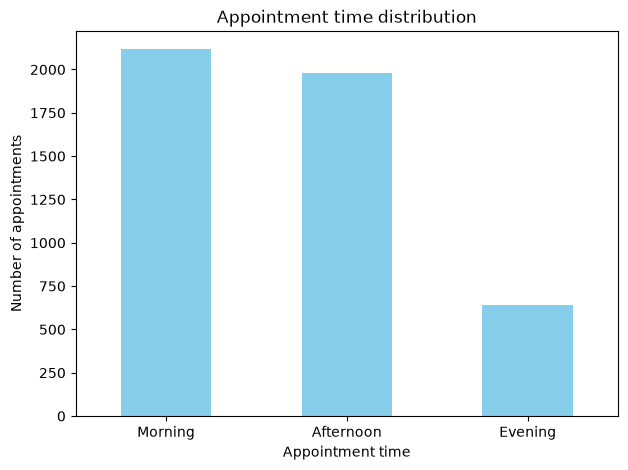

In [144]:
df_prepared["appointment_time"].value_counts().plot(kind="bar",figsize=(7, 5), color="skyblue")

plt.title("Appointment time distribution")
plt.xlabel("Appointment time")
plt.ylabel("Number of appointments")
plt.xticks(rotation=0)
plt.show()

#### 9.3.6 Summary of categorical feature distributions

The categorical feature analysis shows that the dataset contains a reasonable representation of different patient and appointment characteristics. The gender categories are relatively balanced between female and male patients, with a smaller number of patients selecting the Prefer not to say.

The age groups are represented across all categories, although patients aged 65+ account for the largest number of appointments. General Consultations are the most common appointment type, followed by Follow-up appointments, Specialist Consultations, and Diagnostic Tests.

Appointments are relatively evenly distributed across the seven days of the week, while appointment times are mainly concentrated in the Morning and Afternoon periods, with fewer Evening appointments.

Overall, no unexpected categorical values were identified during the analysis. These features can therefore be retained for further exploratory analysis, particularly to investigate whether differences in categorical characteristics are associated with appointment no-show behaviour.

### 9.4 Feature–target relationships

#### 9.4.1 Gender vs No-Show

Gender is analysed against the no-show target to determine whether appointment attendance outcomes differ across the gender categories. This comparison helps identify whether there are noticeable differences in no-show behaviour between female, male, and the Prefer not to say patients.

The analysis will first examine the number of attended and no-show appointments within each gender category. The results will then be visualised to make differences between the groups easier to identify.

In [145]:
gender_no_show_counts = pd.crosstab(df_prepared["gender"], df_prepared["no_show"])

gender_no_show_counts

no_show,0,1
gender,,
Female,1153,1205
Male,1103,1171
Prefer not to say,58,47


The gender versus no-show distribution shows that female patients had 1,153 attended appointments and 1,205 no-show appointments. Male patients had 1,103 attended appointments and 1,171 no-show appointments. For patients who selected the Prefer not to say, there were 58 attended appointments and 47 no-show appointments.

The numbers for female and male patients are relatively similar, with both groups showing slightly more no-show appointments than attended appointments. The Prefer not to say group shows the opposite pattern, with more attended appointments than no-shows, although this group is much smaller than the female and male groups.

These results suggest that there may be some differences in no-show behaviour across gender categories. However, the differences should not be considered conclusive based on counts alone, and further statistical analysis can be used later to determine whether the observed relationship is statistically significant.

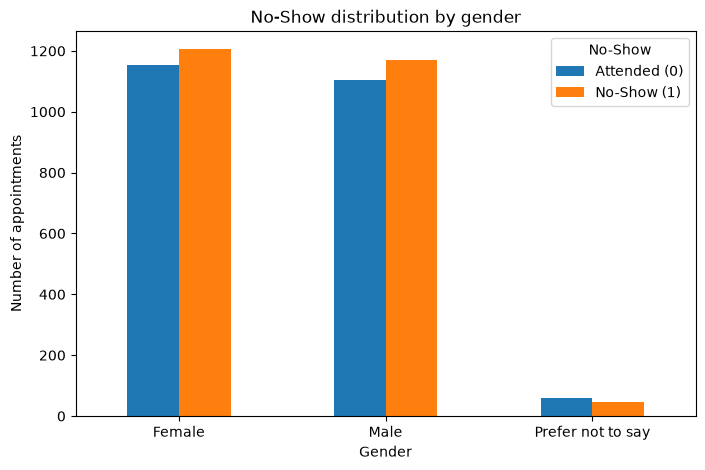

In [147]:
gender_no_show_counts.plot(kind="bar",figsize=(8, 5))

plt.title("No-Show distribution by gender")
plt.xlabel("Gender")
plt.ylabel("Number of appointments")
plt.xticks(rotation=0)
plt.legend(title="No-Show", labels=["Attended (0)", "No-Show (1)"])
plt.show()

#### 9.4.2 Age group vs No-Show

Age group is analysed against the no-show target to determine whether appointment attendance outcomes differ across different age categories. This comparison helps identify whether certain age groups appear to have higher or lower levels of no-show behaviour.

The analysis will first examine the number of attended and no-show appointments within each age group. The results will then be visualised to make differences in appointment outcomes across age groups easier to identify.

In [148]:
age_group_no_show_counts = pd.crosstab(df_prepared["age_group"],df_prepared["no_show"])

age_group_no_show_counts

no_show,0,1
age_group,,
18-24,257,283
25-34,353,397
35-44,374,396
45-54,365,381
55-64,360,406
65+,605,560


The age group versus no-show distribution shows differences in appointment outcomes across the different age categories. The 18–24 age group had 257 attended appointments and 283 no-show appointments, while the 25–34 age group had 353 attended appointments and 397 no-show appointments.

The 35–44 age group had 374 attended appointments and 396 no-show appointments, and the 45–54 age group had 365 attended appointments and 381 no-show appointments. The 55–64 age group recorded 360 attended appointments and 406 no-show appointments.

The 65+ age group had the highest number of attended appointments, with 605 appointments, and 560 no-show appointments. Unlike the other age groups, this group had more attended appointments than no-show appointments.

Overall, the results suggest that no-show behaviour may differ across age groups. The 18–24, 25–34, 35–44, 45–54, and 55–64 groups all recorded slightly more no-show appointments than attended appointments, whereas the 65+ group recorded more attended appointments than no-shows. However, these counts alone do not establish whether age group has a statistically significant relationship with no-show behaviour. This relationship can be investigated further through statistical testing.

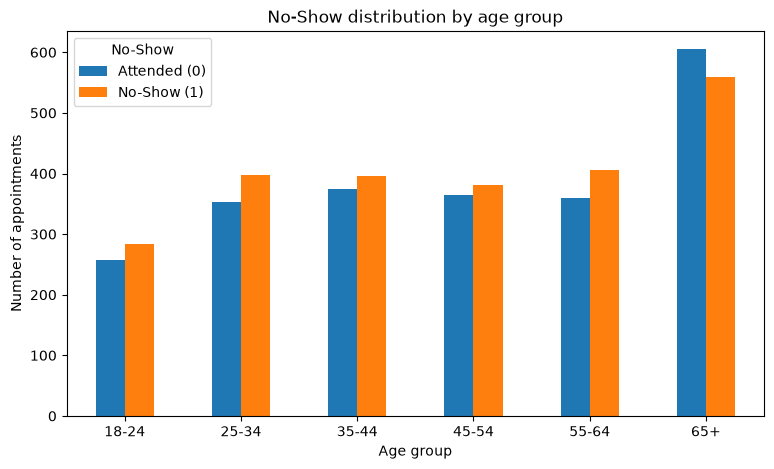

In [149]:
age_group_no_show_counts.plot(kind="bar",figsize=(9, 5))

plt.title("No-Show distribution by age group")
plt.xlabel("Age group")
plt.ylabel("Number of appointments")
plt.xticks(rotation=0)
plt.legend(title="No-Show", labels=["Attended (0)", "No-Show (1)"])
plt.show()

#### 9.4.3 Appointment type vs No-Show

Appointment type is analysed against the no-show target to determine whether attendance outcomes differ across the different types of appointments. This comparison helps identify whether certain appointment types appear to have higher or lower levels of no-show behaviour.

The analysis will first examine the number of attended and no-show appointments within each appointment type. The results will then be visualised to make differences in appointment outcomes across appointment types easier to identify.

In [150]:
appointment_type_no_show_counts = pd.crosstab(df_prepared["appointment_type"],df_prepared["no_show"])

appointment_type_no_show_counts

no_show,0,1
appointment_type,,
Diagnostic Test,272,295
Follow-up,616,728
General Consultation,1007,973
Specialist Consultation,419,427


The appointment type versus no-show distribution shows some differences in attendance outcomes across the four appointment types. Diagnostic Tests had 272 attended appointments and 295 no-show appointments, while Follow-up appointments had 616 attended appointments and 728 no-show appointments.

General Consultations had 1,007 attended appointments and 973 no-show appointments. This is the only appointment type where attended appointments were slightly higher than no-show appointments. Specialist Consultations had 419 attended appointments and 427 no-show appointments, showing a relatively small difference between the two outcomes.

Overall, Follow-up appointments recorded the largest difference between attended and no-show appointments, with more no-shows than attended appointments. General Consultations showed a slightly different pattern, with more attended appointments than no-shows. These differences suggest that appointment type may have a relationship with no-show behaviour. However, the counts alone cannot determine whether the observed differences are statistically significant, so further analysis will be required.

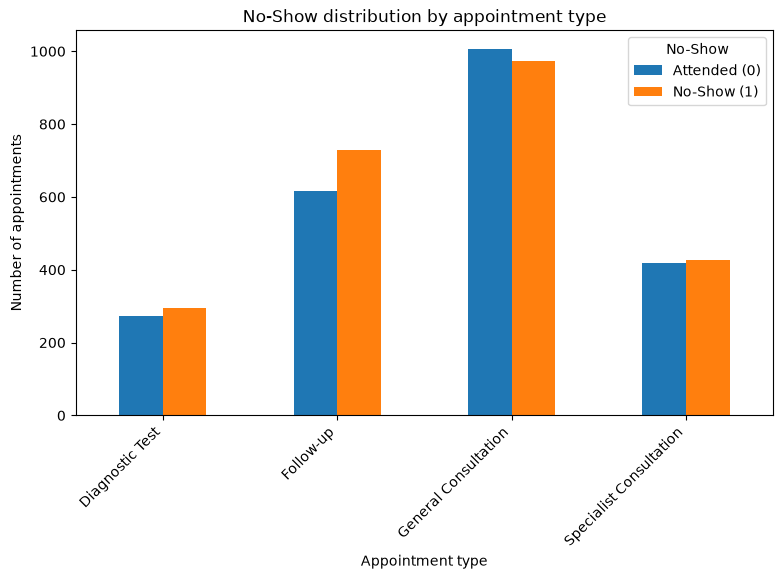

In [151]:
appointment_type_no_show_counts.plot(kind="bar",figsize=(9, 5))

plt.title("No-Show distribution by appointment type")
plt.xlabel("Appointment type")
plt.ylabel("Number of appointments")
plt.xticks(rotation=45, ha="right")
plt.legend(title="No-Show",labels=["Attended (0)", "No-Show (1)"])
plt.show()

#### 9.4.4 Appointment day vs No-Show

Appointment day is analysed against the no-show target to determine whether attendance outcomes differ across the days of the week. This comparison helps identify whether certain appointment days appear to have higher or lower levels of no-show behaviour.

The analysis will first examine the number of attended and no-show appointments for each day of the week. The results will then be visualised to make differences in appointment outcomes across the days easier to identify.

In [152]:
appointment_day_no_show_counts = pd.crosstab(df_prepared["appointment_day"],df_prepared["no_show"])

appointment_day_no_show_counts

no_show,0,1
appointment_day,,
Friday,357,339
Monday,307,348
Saturday,344,339
Sunday,332,372
Thursday,309,335
Tuesday,338,324
Wednesday,327,366


The appointment day versus no-show distribution shows some variation in attendance outcomes across the days of the week. Friday had 357 attended appointments and 339 no-show appointments, while Monday had 307 attended appointments and 348 no-show appointments.

Saturday had 344 attended appointments and 339 no-show appointments, showing very similar numbers for the two outcomes. Sunday recorded 332 attended appointments and 372 no-show appointments, representing one of the larger differences between attended and no-show appointments.

Thursday had 309 attended appointments and 335 no-show appointments, while Tuesday had 338 attended appointments and 324 no-show appointments. Wednesday recorded 327 attended appointments and 366 no-show appointments.

Overall, the results show that no-show behaviour varies across appointment days. Monday, Sunday, Thursday, and Wednesday had more no-show appointments than attended appointments, whereas Friday, Saturday, and Tuesday had slightly more attended appointments than no-shows. The differences are not extremely large across the days, but the pattern suggests that appointment day may be worth investigating as a potential predictor of no-show behaviour. However, these counts alone do not establish statistical significance, so further analysis will be required.

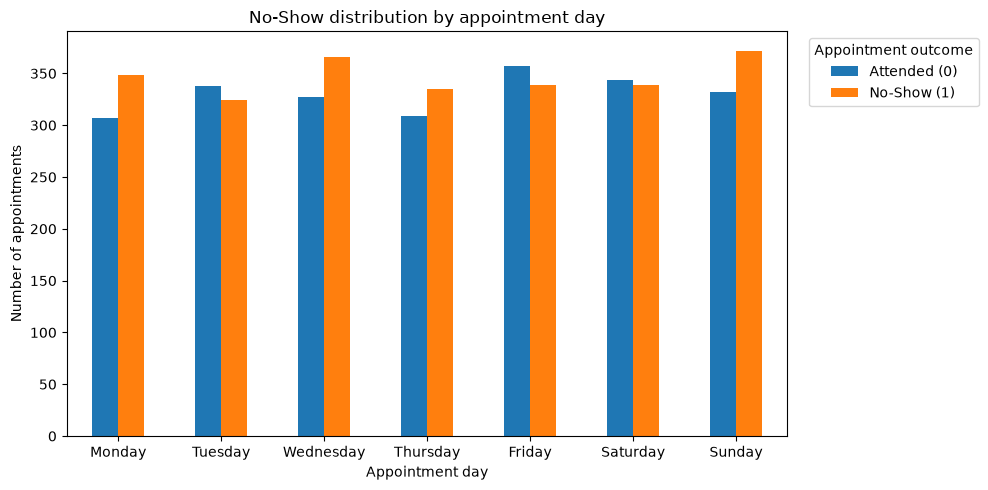

In [156]:
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

appointment_day_no_show_counts = appointment_day_no_show_counts.reindex(day_order)

appointment_day_no_show_counts.plot(kind="bar",figsize=(10, 5))

plt.title("No-Show distribution by appointment day")
plt.xlabel("Appointment day")
plt.ylabel("Number of appointments")
plt.xticks(rotation=0)

plt.legend(title="Appointment outcome",labels=["Attended (0)", "No-Show (1)"], bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

#### 9.4.5 Appointment time vs No-Show

Appointment time is analysed against the no-show target to determine whether attendance outcomes differ across Morning, Afternoon, and Evening appointments. This comparison helps identify whether certain appointment times appear to have higher or lower levels of no-show behaviour.

The analysis will first examine the number of attended and no-show appointments for each appointment time. The results will then be visualised to make differences in appointment outcomes across the different appointment times easier to identify.

In [155]:
appointment_time_no_show_counts = pd.crosstab(df_prepared["appointment_time"],df_prepared["no_show"])

appointment_time_no_show_counts

no_show,0,1
appointment_time,,
Afternoon,966,1013
Evening,304,338
Morning,1044,1072


The appointment time versus no-show distribution shows some variation in attendance outcomes across the different appointment times. Afternoon appointments recorded 966 attended appointments and 1,013 no-show appointments, while Evening appointments recorded 304 attended appointments and 338 no-show appointments.

Morning appointments had 1,044 attended appointments and 1,072 no-show appointments. This indicates that Morning appointments had the highest number of both attended and no-show appointments, which is consistent with Morning also being the most common appointment time in the dataset.

Overall, Afternoon, Evening, and Morning appointments all recorded slightly more no-show appointments than attended appointments. The differences between attended and no-show appointments are relatively small, suggesting that appointment time alone may not have a strong difference in attendance behaviour. However, appointment time remains a potentially useful predictor and can be investigated further alongside other variables.

These counts describe the observed distribution in the dataset but do not establish whether the differences are statistically significant.

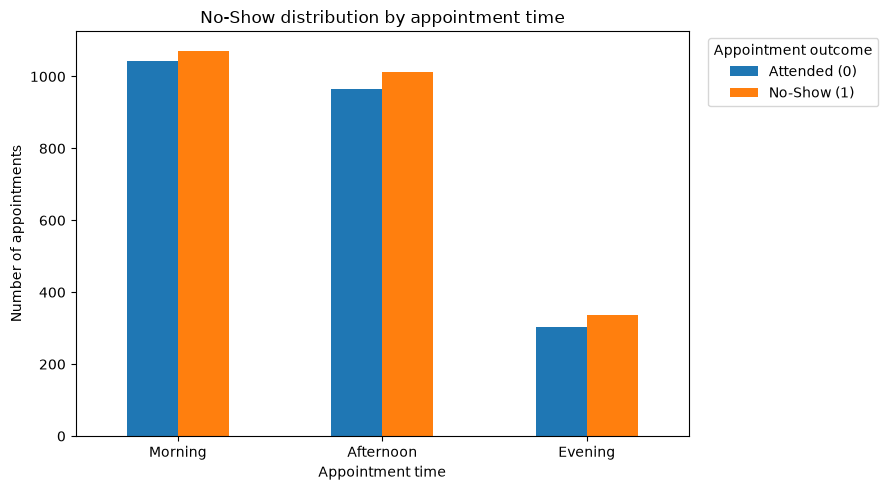

In [157]:
time_order = ["Morning","Afternoon","Evening"]

appointment_time_no_show_counts = appointment_time_no_show_counts.reindex(time_order)

appointment_time_no_show_counts.plot(kind="bar",figsize=(9, 5))

plt.title("No-Show distribution by appointment time")
plt.xlabel("Appointment time")
plt.ylabel("Number of appointments")
plt.xticks(rotation=0)

plt.legend(title="Appointment outcome",labels=["Attended (0)", "No-Show (1)"], bbox_to_anchor=(1.02, 1),loc="upper left"
)

plt.tight_layout()
plt.show()

#### 9.4.6 Booking lead time vs No-Show

Booking lead time represents the number of days between the date an appointment was booked and the scheduled appointment date. This feature is analysed against the no-show target to determine whether appointments booked further in advance show different attendance patterns compared with appointments booked closer to the appointment date.

The analysis will first examine the distribution of booking lead time for attended and no-show appointments. The results will then be visualised to identify whether longer or shorter booking lead times appear to be associated with different no-show behaviour.

In [158]:
lead_time_bins = [0, 7, 14, 30, 45, 60]
lead_time_labels = ["0–7 days","8–14 days","15–30 days","31–45 days","46–60 days"]

df_prepared["booking_lead_group"] = pd.cut(df_prepared["booking_lead_days"],bins=lead_time_bins,labels=lead_time_labels,include_lowest=True)

booking_lead_no_show_counts = pd.crosstab(df_prepared["booking_lead_group"],df_prepared["no_show"])

booking_lead_no_show_counts

no_show,0,1
booking_lead_group,,
0–7 days,426,178
8–14 days,372,202
15–30 days,689,576
31–45 days,510,677
46–60 days,317,790


The booking lead time versus no-show distribution shows a noticeable change in attendance behaviour as the time between booking and the appointment increases.

Appointments booked 0–7 days in advance recorded 426 attended appointments and 178 no-show appointments. For appointments booked 8–14 days in advance, there were 372 attended appointments and 202 no-show appointments.

For the 15–30 day group, 689 appointments were attended compared with 576 no-shows. The 31–45 day group showed a different pattern, with 510 attended appointments and 677 no-shows.

The strongest difference was observed for appointments booked 46–60 days in advance, where 317 appointments were attended and 790 were no-shows. This indicates that longer booking lead times may be associated with a higher likelihood of missing an appointment.

Overall, the results suggest a potential relationship between booking lead time and no-show behaviour. As booking lead time increases, the number of no-show appointments generally becomes larger relative to attended appointments. This makes booking lead time an important feature to investigate further during feature analysis and modelling.

These results show an observed association in the dataset and do not by themselves establish that booking lead time causes patients to miss appointments.

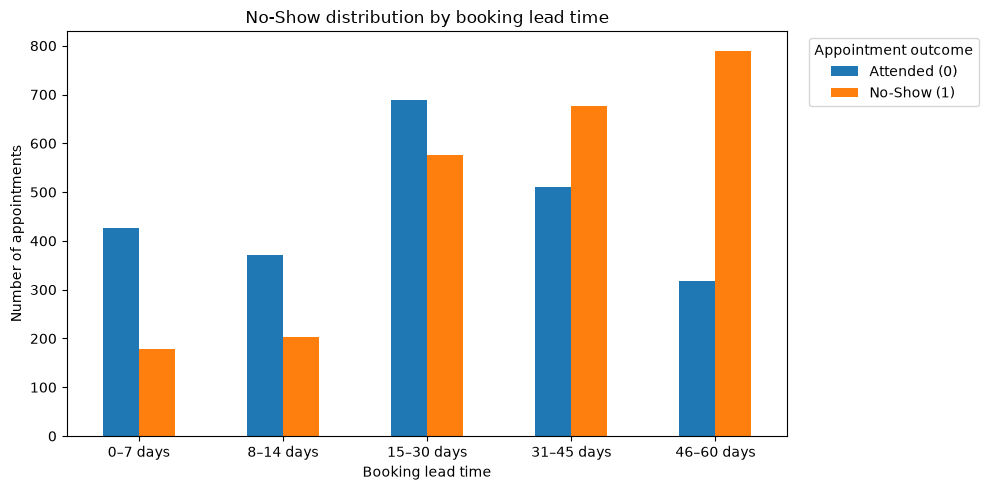

In [159]:
lead_time_order = ["0–7 days","8–14 days","15–30 days","31–45 days","46–60 days"]

booking_lead_no_show_counts = booking_lead_no_show_counts.reindex(lead_time_order)

booking_lead_no_show_counts.plot(kind="bar",figsize=(10, 5))

plt.title("No-Show distribution by booking lead time")
plt.xlabel("Booking lead time")
plt.ylabel("Number of appointments")
plt.xticks(rotation=0)

plt.legend(title="Appointment outcome",labels=["Attended (0)", "No-Show (1)"],bbox_to_anchor=(1.02, 1),loc="upper left")
plt.tight_layout()
plt.show()

#### 9.4.7 Previous No-Shows vs No-Show

Previous no-shows represent the number of appointments a patient had previously missed before the current appointment. This feature is analysed against the current no-show target to determine whether patients with a history of missed appointments show different attendance behaviour.

The analysis will first examine the number of attended and no-show appointments across different levels of previous no-shows. The results will then be visualised to determine whether a history of missed appointments appears to be associated with current no-show behaviour.

In [160]:
previous_no_show_counts = pd.crosstab(df_prepared["previous_no_shows"],df_prepared["no_show"])

previous_no_show_counts

no_show,0,1
previous_no_shows,,
0,1474,1271
1,654,828
2,159,260
3,23,53
4,4,8
5,0,3


The previous no-shows versus current no-show distribution shows a noticeable relationship between a patient's history of missed appointments and their attendance at the current appointment.

Patients with 0 previous no-shows recorded 1,474 attended appointments compared with 1,271 no-show appointments. In contrast, patients with 1 previous no-show recorded 654 attended appointments and 828 no-show appointments. A similar pattern was observed among patients with 2 previous no-shows, where there were 159 attended appointments compared with 260 no-shows.

For patients with 3 previous no-shows, 23 appointments were attended while 53 were no-shows. The groups with 4 and 5 previous no-shows were much smaller, with 4 attended and 8 no-show appointments for the group with 4 previous no-shows, and 0 attended and 3 no-show appointments for the group with 5 previous no-shows.

Overall, the results suggest that patients with a history of previous no-shows may be more likely to miss their current appointment. The difference is particularly noticeable when comparing patients with no previous no-shows to those with at least one previous no-show.

However, the groups with higher numbers of previous no-shows contain relatively few observations, so these results should be interpreted cautiously. These counts show an observed association between previous no-shows and current no-show behaviour but do not establish that previous no-shows directly cause future no-shows. Further statistical analysis and modelling will be required to determine the strength and significance of this relationship.

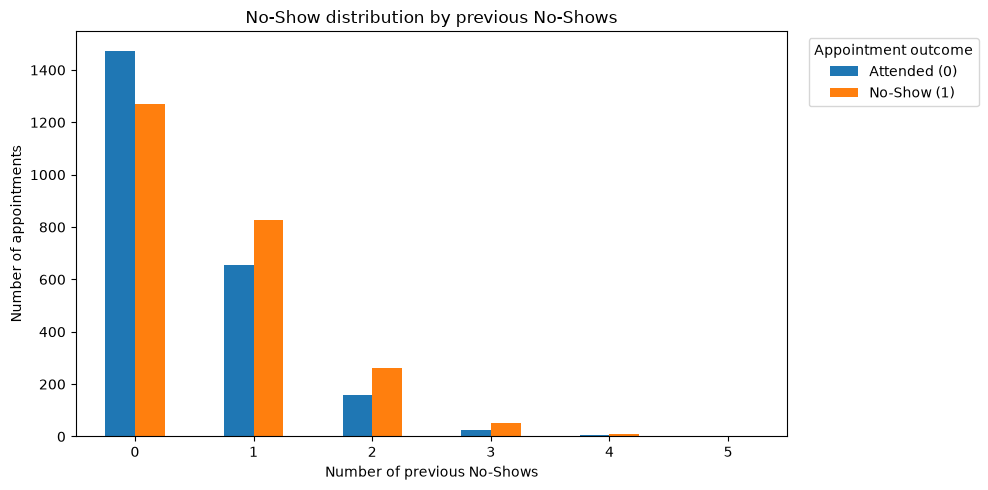

In [161]:
previous_no_show_counts.plot(kind="bar",figsize=(10, 5))

plt.title("No-Show distribution by previous No-Shows")
plt.xlabel("Number of previous No-Shows")
plt.ylabel("Number of appointments")
plt.xticks(rotation=0)

plt.legend(title="Appointment outcome",labels=["Attended (0)", "No-Show (1)"],bbox_to_anchor=(1.02, 1),loc="upper left")
plt.tight_layout()
plt.show()

#### 9.4.8 Distance to clinic vs No-Show

Distance to clinic represents the approximate distance between the patient's location and the clinic. This feature is analysed against the no-show target to determine whether attendance outcomes differ for patients who live closer to or further away from the clinic.

The analysis will first group patients according to their distance from the clinic and examine the number of attended and no-show appointments within each distance group. The results will then be visualised to identify whether greater distance from the clinic appears to be associated with different no-show behaviour.

In [163]:
distance_bins = [0, 5, 10, 15, 20, 30, 50]

distance_labels = ["0–5 km","6–10 km","11–15 km","16–20 km","21–30 km","31–50 km"]

df_prepared["distance_group"] = pd.cut(df_prepared["distance_to_clinic_km"],bins=distance_bins,labels=distance_labels,include_lowest=True)

distance_no_show_counts = pd.crosstab(df_prepared["distance_group"],df_prepared["no_show"])

distance_no_show_counts

no_show,0,1
distance_group,,
0–5 km,566,537
6–10 km,847,834
11–15 km,520,549
16–20 km,233,276
21–30 km,127,178
31–50 km,21,49


The distance to clinic versus no-show distribution shows some variation in attendance behaviour across the different distance groups. For appointments within 0–5 km of the clinic, there were 566 attended appointments and 537 no-show appointments. The 6–10 km group recorded 847 attended appointments and 834 no-show appointments, showing a very similar distribution between the two outcomes.

For appointments located 11–15 km from the clinic, there were 520 attended appointments compared with 549 no-show appointments. The difference became more noticeable in the 16–20 km group, which recorded 233 attended appointments and 276 no-show appointments.

The 21–30 km group showed a larger difference, with 127 attended appointments compared with 178 no-shows. The 31–50 km group had the smallest number of appointments, with 21 attended appointments and 49 no-shows.

Overall, the results suggest that no-show appointments become more common relative to attended appointments as the distance from the clinic increases. The difference is particularly noticeable among appointments more than 20 km from the clinic. This suggests that distance to the clinic may be a useful predictor of no-show behaviour.

However, the 31–50 km group contains relatively few observations, so the pattern in this group should be interpreted cautiously. These results show an observed association between distance to the clinic and no-show behaviour but do not establish that greater distance directly causes patients to miss appointments. Further statistical analysis and modelling will be required to assess the strength of this relationship.

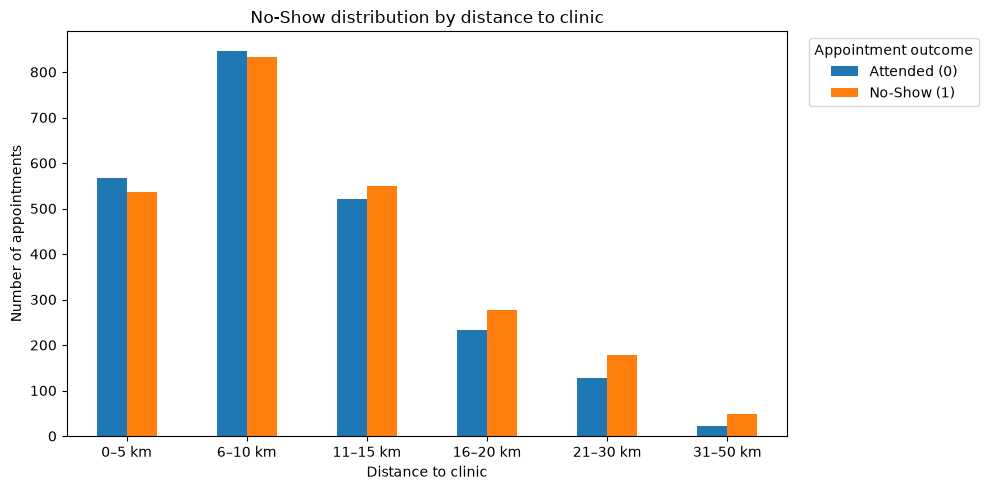

In [167]:
distance_order = ["0–5 km","6–10 km","11–15 km","16–20 km","21–30 km","31–50 km"]

distance_no_show_counts = distance_no_show_counts.reindex(distance_order)

distance_no_show_counts.plot(kind="bar",figsize=(10, 5))

plt.title("No-Show distribution by distance to clinic")
plt.xlabel("Distance to clinic")
plt.ylabel("Number of appointments")
plt.xticks(rotation=0)

plt.legend(title="Appointment outcome",labels=["Attended (0)", "No-Show (1)"],bbox_to_anchor=(1.02, 1),loc="upper left")
plt.tight_layout()
plt.show()

#### 9.4.9 Previous appointments vs No-Show

Previous appointments represent the number of appointments a patient had before the current appointment. This feature is analysed against the no-show target to determine whether patients with different levels of previous appointment history show different attendance behaviour.

The analysis will first examine the number of attended and no-show appointments across different levels of previous appointments. The results will then be visualised to identify whether a patient's previous appointment history appears to be associated with their current attendance behaviour.

In [165]:
previous_appointments_no_show_counts = pd.crosstab(df_prepared["previous_appointments"],df_prepared["no_show"])

previous_appointments_no_show_counts

no_show,0,1
previous_appointments,,
0,124,104
1,362,344
2,534,525
3,483,557
4,407,412
5,219,252
6,105,127
7,59,62
8,14,31


The previous appointments versus current no-show distribution shows some variation in attendance behaviour across patients with different numbers of previous appointments.

Patients with 0 previous appointments recorded 124 attended appointments and 104 no-show appointments. The 1 previous appointment group recorded 362 attended appointments and 344 no-shows, while the 2 previous appointments group recorded 534 attended appointments and 525 no-shows. These groups show relatively similar numbers of attended and no-show appointments.

For patients with 3 previous appointments, there were 483 attended appointments compared with 557 no-shows. This was one of the clearer differences in the distribution, with no-shows exceeding attended appointments. The 4 previous appointments group had 407 attended appointments and 412 no-shows, while the 5 previous appointments group recorded 219 attended appointments and 252 no-shows.

The groups with 6 and 7 previous appointments also showed slightly more no-shows than attended appointments. The 8 previous appointments group recorded 14 attended appointments and 31 no-shows. However, the groups with 9, 10, and 11 previous appointments contained very few observations, making it difficult to draw reliable conclusions from these groups.

Overall, the results suggest that previous appointment history may have some association with current no-show behaviour, particularly for patients with around 3 or more previous appointments. However, the relationship is not consistently increasing or decreasing across all groups. The smaller groups at higher numbers of previous appointments should also be interpreted cautiously.

These counts describe observed patterns in the dataset but do not establish that previous appointment history directly causes a patient to miss an appointment. Further statistical analysis and modelling will be required to determine whether this feature provides meaningful predictive information.

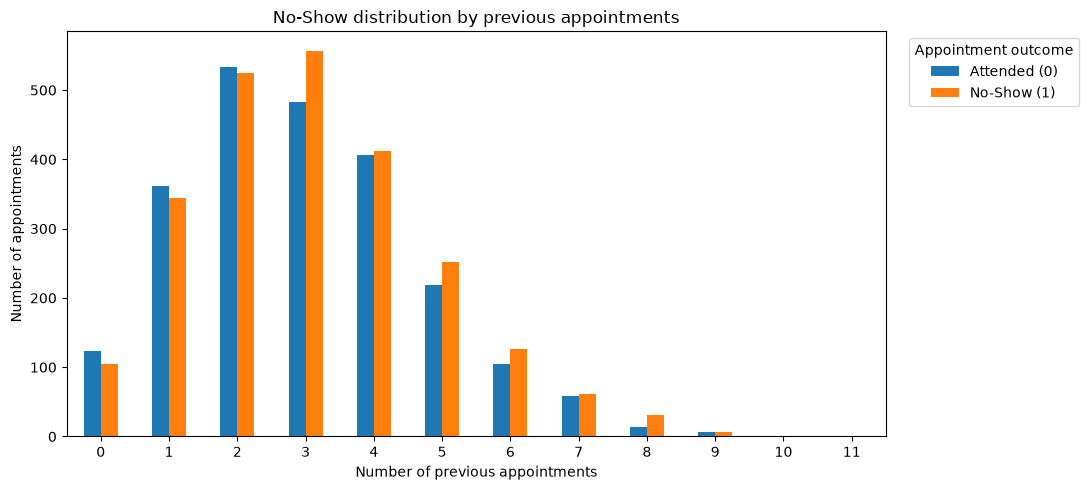

In [168]:
previous_appointments_no_show_counts.plot(kind="bar",figsize=(11, 5))

plt.title("No-Show distribution by previous appointments")
plt.xlabel("Number of previous appointments")
plt.ylabel("Number of appointments")
plt.xticks(rotation=0)

plt.legend(title="Appointment outcome",labels=["Attended (0)", "No-Show (1)"],bbox_to_anchor=(1.02, 1),loc="upper left")
plt.tight_layout()
plt.show()

#### 9.4.10 Summary of feature–target relationships

The feature–target analysis identified several differences in no-show behaviour across the candidate predictors.

Gender showed relatively similar attendance patterns between male and female patients, with both groups recording slightly more no-show appointments than attended appointments. The "Prefer not to say" group showed a slightly different pattern but contained substantially fewer observations.

Age group showed more noticeable differences. Most age groups between 18 and 64 years recorded more no-show appointments than attended appointments, while the 65+ group recorded more attended appointments than no-shows. This suggests that age group may provide useful information for predicting no-show behaviour.

Appointment type also showed variation. Follow-up appointments recorded more no-shows than attended appointments, while General Consultation appointments recorded slightly more attended appointments than no-shows. Diagnostic Test and Specialist Consultation appointments also showed more no-shows than attended appointments.

Appointment day showed relatively small differences between attended and no-show appointments. Monday, Wednesday, Thursday, and Sunday recorded more no-shows than attended appointments, while Tuesday, Friday, and Saturday recorded slightly more attended appointments.

Appointment time showed only small differences between the two outcomes. Morning, Afternoon, and Evening appointments all recorded slightly more no-shows than attended appointments. Therefore, appointment time may provide some predictive information but does not appear to show a strong difference on its own.

Booking lead time showed one of the clearest patterns. Appointments booked further in advance, particularly those in the 31–45 day and 46–60 day groups, had substantially more no-shows than attended appointments. This suggests that booking lead time may be an important predictor of no-show behaviour.

Previous no-shows also showed a noticeable relationship with the current no-show outcome. Patients with at least one previous no-show generally had more current no-show appointments than attended appointments. However, groups with higher numbers of previous no-shows contained fewer observations and should therefore be interpreted cautiously.

Distance to the clinic showed a potential relationship with no-show behaviour. The difference between attended and no-show appointments became more noticeable as distance increased, particularly for appointments more than 20 km from the clinic. However, the highest-distance group contained relatively few observations.

Previous appointments showed a less consistent pattern. Most groups had relatively similar numbers of attended and no-show appointments, although some groups, particularly patients with 3 or more previous appointments, showed more no-shows. The groups with very high numbers of previous appointments contained few observations.

Overall, the feature–target analysis suggests that booking lead time, previous no-shows, age group, and distance to the clinic may contain useful predictive information for appointment no-show behaviour. Appointment type and previous appointment history may also contribute to prediction, while gender, appointment day, and appointment time showed smaller differences.

These observations describe patterns in the dataset and do not establish causation or statistical significance. The strength and predictive value of these relationships will be assessed further using statistical analysis and machine learning models.

### 9.5 Correlation analysis

Correlation analysis is used to examine the strength and direction of relationships between the numerical features in the prepared dataset.

This analysis will focus on the numerical predictors, including age, booking lead time, previous appointments, previous no-shows, and distance to the clinic. Examining these relationships can help identify whether some numerical features are strongly related to one another and may provide additional insight into the structure of the dataset.

Correlation does not imply causation. The results will therefore be used to identify patterns and potential relationships rather than to conclude that one variable causes changes in another.

#### 9.5.1 Numerical correlation matrix

The correlation matrix is used to measure the strength and direction of linear relationships between the numerical features in the prepared dataset.

Correlation coefficients range from -1 to +1. Values close to +1 indicate a strong positive relationship, values close to -1 indicate a strong negative relationship, and values close to 0 indicate a weak or negligible linear relationship.

The correlation matrix will be examined to identify whether any numerical predictors are strongly related to one another. This can help identify potential redundancy between features before model development.

In [169]:
numerical_correlation = df_prepared[numerical_features].corr()

numerical_correlation

,age,booking_lead_days,previous_appointments,previous_no_shows,distance_to_clinic_km
age,1.000000,-0.026342,-0.005648,0.013150,-0.000193
booking_lead_days,-0.026342,1.000000,0.002704,0.007648,-0.006326
previous_appointments,-0.005648,0.002704,1.000000,0.460674,-0.004700
previous_no_shows,0.013150,0.007648,0.460674,1.000000,0.005847
distance_to_clinic_km,-0.000193,-0.006326,-0.004700,0.005847,1.000000


The correlation matrix shows that most numerical features have very weak linear relationships with one another, with correlation coefficients close to zero.

The strongest observed relationship is between previous appointments and previous no-shows, with a correlation coefficient of approximately 0.461. This represents a moderate positive relationship. This pattern is reasonable because patients with a greater history of appointments have had more opportunities to accumulate previous no-shows.

The remaining numerical feature pairs show very weak correlations, generally close to zero. This suggests that the numerical predictors provide relatively distinct information and that there is no strong evidence of multicollinearity among the features at this stage.

The moderate relationship between previous appointments and previous no-shows will be retained because both variables may provide useful information for predicting current no-show behaviour. The correlation does not by itself justify removing either feature.

Overall, the correlation analysis suggests that the numerical predictors are largely independent of one another, while the relationship between previous appointments and previous no-shows should be considered when interpreting the model.

#### 9.5.2 Correlation heatmap

A correlation heatmap provides a visual representation of the relationships between the numerical features. The colour intensity makes it easier to identify stronger positive or negative correlations and to compare relationships across multiple variables.

The heatmap will be based on the correlation matrix calculated in the previous step. This allows the numerical findings to be visually confirmed without introducing additional calculations.

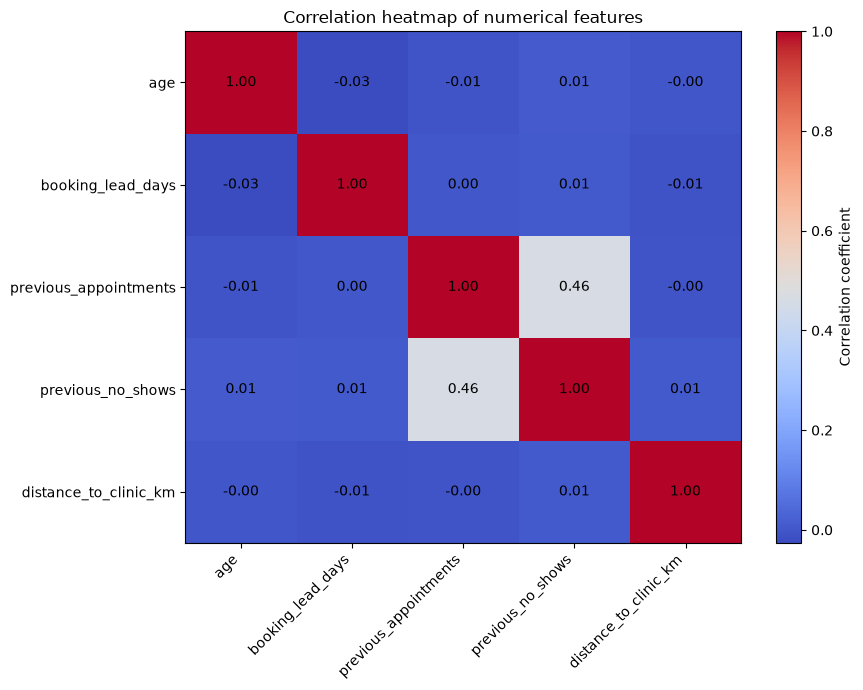

In [170]:
plt.figure(figsize=(9, 7))

plt.imshow(numerical_correlation,cmap="coolwarm",aspect="auto")

plt.colorbar(label="Correlation coefficient")

plt.xticks(range(len(numerical_correlation.columns)),numerical_correlation.columns,rotation=45,ha="right")

plt.yticks(range(len(numerical_correlation.index)),numerical_correlation.index)

for i in range(len(numerical_correlation.index)):
    for j in range(len(numerical_correlation.columns)):
        plt.text(j,i, f"{numerical_correlation.iloc[i, j]:.2f}", ha="center",va="center")

plt.title("Correlation heatmap of numerical features")
plt.tight_layout()
plt.show()

#### 9.5.3 Correlation analysis summary

The correlation analysis shows that most numerical features in the prepared dataset have very weak linear relationships with one another. The strongest relationship is between previous appointments and previous no-shows, with a correlation coefficient of approximately 0.461, indicating a moderate positive relationship.

The remaining numerical feature pairs have correlation coefficients close to zero, suggesting that they provide relatively distinct information. Therefore, there is no strong evidence of multicollinearity among the numerical predictors at this stage.

The relationship between previous appointments and previous no-shows will be retained because both variables may provide useful predictive information about current no-show behaviour. The correlation analysis will also be considered during model interpretation.

Overall, the correlation analysis indicates that the numerical predictors can be retained for further analysis and model development without an immediate need to remove features because of strong correlations.

### 9.6 EDA findings

The exploratory data analysis provided an overall understanding of the distribution of the target variable, the characteristics of the predictor variables, and the observed relationships between the predictors and appointment no-show behaviour.

Several important patterns were identified during the analysis. These findings will be used to guide feature engineering, feature selection, and model development in the next stages of the project.

## 10. Feature engineering

Feature engineering involves creating new variables from existing information to provide the machine learning model with more useful representations of the underlying patterns.

For this project, feature engineering will focus on information that is available at the prediction point and that may help explain appointment attendance behaviour.

The EDA identified several potentially useful areas for feature engineering, including booking lead time, previous attendance behaviour, appointment timing, and patient characteristics.

New features will only be created when they have a clear interpretation and a reasonable connection to the prediction problem. Features that could introduce data leakage or use information that would not be available before the appointment will not be created.

### 10.1 Feature engineering opportunities

Based on the exploratory analysis, the following feature engineering opportunities were identified:

1. Booking lead-time grouping

   Booking lead time showed a noticeable relationship with no-show behaviour, particularly for appointments booked further in advance. A grouped   version of booking lead time may allow the model to capture differences between short, medium, and long waiting periods.

2. Previous no-show history

   Previous no-shows showed a relatively clear relationship with the current no-show outcome. This existing variable already captures previous attendance behaviour and therefore does not require unnecessary transformation at this stage.

3. Previous appointment history

   Previous appointments may provide information about a patient's experience with the clinic. However, because the existing variable already represents this history numerically, it will initially be retained without creating multiple additional versions of the same information.

4. Appointment timing

   Appointment day and appointment time may contain useful information about attendance behaviour. These variables are already represented as categorical features and can be encoded during model preprocessing.

5. Age groups

   Age groups were already created during data preparation and provide a categorical representation of age. Therefore, an additional age transformation is not necessary at this stage.

6. Distance to clinic

   Distance showed a possible relationship with no-show behaviour, particularly at greater distances. A grouped distance feature may provide the model with a simpler representation of proximity to the clinic.

Overall, the main new features considered for creation are grouped booking lead time and grouped distance to the clinic. These features will be evaluated carefully to determine whether they add useful information without unnecessarily increasing model complexity.

### 10.2 Create engineered features

Two engineered categorical features will be created based on patterns identified during the exploratory data analysis.

The first feature, booking_lead_group, will group appointments according to the number of days between booking and the scheduled appointment. This may help the model capture differences between short, medium, and long booking lead times.

The second feature, distance_group, will group patients according to their distance from the clinic. The EDA suggested that no-show behaviour became more noticeable at greater distances, particularly beyond 20 km.

The original numerical variables will be retained because they contain more detailed information than the grouped versions. The engineered categorical features will therefore provide an alternative representation rather than replacing the original variables.

In [171]:
# Creating the booking lead-time groups

lead_time_bins = [0, 7, 14, 30, 45, 60]

lead_time_labels = ["0–7 days","8–14 days","15–30 days","31–45 days","46–60 days"]

df_prepared["booking_lead_group"] = pd.cut(df_prepared["booking_lead_days"],bins=lead_time_bins,labels=lead_time_labels,include_lowest=True)

# Creating distance-to-clinic groups

distance_bins = [0, 5, 10, 15, 20, 30, 50]

distance_labels = ["0–5 km","6–10 km","11–15 km","16–20 km","21–30 km","31–50 km"]

df_prepared["distance_group"] = pd.cut(df_prepared["distance_to_clinic_km"],bins=distance_bins,labels=distance_labels,include_lowest=True)

In [172]:
df_prepared[["booking_lead_days","booking_lead_group","distance_to_clinic_km","distance_group"]].head(10)

,booking_lead_days,booking_lead_group,distance_to_clinic_km,distance_group
0,12,8–14 days,19.3,16–20 km
1,2,0–7 days,14.3,11–15 km
2,38,31–45 days,11.4,11–15 km
3,41,31–45 days,7.4,6–10 km
4,47,46–60 days,5.6,6–10 km
5,57,46–60 days,3.1,0–5 km
6,30,15–30 days,8.2,6–10 km
7,50,46–60 days,19.2,16–20 km
8,43,31–45 days,10.1,11–15 km
9,16,15–30 days,28.0,21–30 km


### 10.3 Validate engineered Features

The newly created engineered features will be validated to ensure that the grouping process was applied correctly and that all observations have been assigned to an appropriate category.

The validation will examine the number of observations in each booking lead-time group and distance group. Missing values in the engineered features will also be checked to ensure that no valid observations were left unclassified.

This step is important because incorrectly defined groups could introduce errors into the modelling dataset.

In [173]:
print("Booking lead-time groups:")
print(df_prepared["booking_lead_group"].value_counts().sort_index())

Booking lead-time groups:
booking_lead_group
0–7 days       604
8–14 days      574
15–30 days    1265
31–45 days    1187
46–60 days    1107
Name: count, dtype: int64


In [174]:
print("\nDistance groups:")
print(df_prepared["distance_group"].value_counts().sort_index())


Distance groups:
distance_group
0–5 km      1103
6–10 km     1681
11–15 km    1069
16–20 km     509
21–30 km     305
31–50 km      70
Name: count, dtype: int64


In [175]:
print("Missing values in engineered features:")

print(df_prepared[["booking_lead_group", "distance_group"]].isnull().sum())

Missing values in engineered features:
booking_lead_group    0
distance_group        0
dtype: int64


The validation confirms that all observations were successfully assigned to a booking lead-time group and a distance-to-clinic group.

The booking lead-time feature contains observations across all five defined groups, with the largest number of appointments falling within the 15–30 day group. The distance feature also contains observations across all six defined groups, with the 6–10 km group containing the largest number of appointments.

No missing values were identified in either engineered feature. The total number of observations across the groups also corresponds to the 4,737 records in the prepared dataset.

These results indicate that the grouping rules were applied consistently and did not result in unclassified observations. The engineered features can therefore be retained for consideration during feature selection and model development.

### 10.4 Feature engineering summary

Feature engineering was performed to create additional variables that may help the machine learning model identify meaningful patterns in appointment no-shows.

Two new categorical features were created:

- booking_lead_group — groups the number of days between booking and the appointment into five categories: 0–7 days, 8–14 days, 15–30 days, 31–45 days, and 46–60 days.
- distance_group — groups the distance to the clinic into six categories: 0–5 km, 6–10 km, 11–15 km, 16–20 km, 21–30 km, and 31–50 km.

The original numerical variables, booking_lead_days and distance_to_clinic_km, were retained because they contain more detailed information than the grouped versions.

The engineered features were validated by checking their category distributions and confirming that all 4,737 observations were assigned to a valid category with no missing or unclassified values.

These engineered features will be considered during feature selection. Their final inclusion in the modelling dataset will be based on their relevance to the prediction objective, potential redundancy, and usefulness during model development.

## 11. Feature selection

### 11.1 Selected features

Feature selection is used to identify the variables that will be considered as predictors of appointment no-shows.

The selection is based on the business problem, the prediction time availability of the variables, the findings from the exploratory data analysis, and the feature engineering performed in Section 10.

The selected features should provide information that would reasonably be available before the scheduled appointment and should have a meaningful relationship with the likelihood of a patient not attending.

The candidate predictors include demographic characteristics, appointment characteristics, booking behaviour, previous appointment history, and distance to the clinic.

Both the original numerical variables and the engineered categorical variables will initially be retained. Their final contribution to the model will be assessed during model development.

In [176]:
selected_features = ["gender","age","age_group","appointment_type","appointment_day",
                     "appointment_time","booking_lead_days","booking_lead_group",
                     "previous_appointments","previous_no_shows","distance_to_clinic_km",
                     "distance_group"]

print("Selected features:")
for feature in selected_features:
    print("-", feature)

print("\nNumber of selected features:", len(selected_features))

Selected features:
- gender
- age
- age_group
- appointment_type
- appointment_day
- appointment_time
- booking_lead_days
- booking_lead_group
- previous_appointments
- previous_no_shows
- distance_to_clinic_km
- distance_group

Number of selected features: 12


The feature selection step identified 12 candidate predictors for the appointment no-show model.

The selected features cover several relevant dimensions of the appointment process:

- gender, age, and age_group represent demographic characteristics.
- appointment_type, appointment_day, and appointment_time represent appointment characteristics.
- booking_lead_days and booking_lead_group represent how far in advance the appointment was booked.
- previous_appointments and previous_no_shows represent the patient's previous appointment history.
- distance_to_clinic_km and distance_group represent the patient's distance from the clinic.

These variables were selected because they are available before the appointment takes place and are therefore potentially suitable for making a prediction in advance.

The original numerical variables were retained alongside their grouped versions at this stage. This allows the modelling process to determine whether the detailed numerical information, the broader grouped information, or both provide useful predictive information.

The 12 variables will be carried forward as candidate predictors. Further assessment during modelling may identify variables that contribute little predictive value or provide redundant information.

### 11.2 Excluded features

Several variables were excluded from the predictor set because they were either identifiers, outcomes that would only be known after the appointment, or variables that could introduce data leakage.

The following variables were excluded:

- appointment_id — excluded because it is a unique identifier and does not provide meaningful predictive information.
- patient_id — excluded because it is an identifier rather than a behavioural or clinical predictor.
- appointment_outcome — excluded because it contains information about the outcome of the appointment and would not be known at the time of prediction.
- waiting_time_minutes — excluded because the waiting time can only be determined after the patient attends or interacts with the clinic.
- reminder_sent — excluded because whether a reminder was sent may depend on processes occurring after the prediction point and could introduce information leakage.
- reminder_channel — excluded for the same reason as reminder_sent; the reminder process may not be known when the prediction is made.
- no-show — excluded because it was a duplicate representation of the target variable no_show.
- booking_date — excluded from the predictor set because it is retained as a date field for reference but is not directly used as a model predictor in its raw form.
- appointment_date — excluded from the predictor set because the raw date itself is not used directly as a predictor. Relevant appointment timing information is represented through engineered features such as appointment_day and appointment_time.

The target variable no_show is also kept separate from the predictor variables because it represents the outcome that the model is attempting to predict.

### 11.3 Feature selection rationale

The selected features were chosen based on their relevance to the appointment no-show prediction problem, their availability before the appointment, and the patterns identified during exploratory data analysis.

The feature selection rationale is as follows:

- Demographic variables such as gender, age, and age_group were retained because differences in no-show behaviour were observed across demographic groups.
- Appointment characteristics such as appointment_type, appointment_day, and appointment_time were retained because the EDA showed some variation in no-show patterns across appointment types and scheduling periods.
- booking_lead_days was retained because the EDA showed a clear relationship between longer booking lead times and higher numbers of no-shows.
- booking_lead_group was created to capture broader patterns associated with different booking lead-time intervals.
- previous_appointments was retained because previous appointment history may provide information about patient engagement with healthcare services.
- previous_no_shows was retained because the EDA showed a clear association between previous no-shows and the likelihood of a current no-show.
- distance_to_clinic_km was retained because greater distance showed an association with increased no-show behaviour.
- distance_group was created to represent broader distance categories and allow the model to capture potential non-linear patterns.

The excluded variables were removed because they were identifiers, duplicate target information, post-outcome variables, or variables that could introduce data leakage.

Although some selected features may show relatively weak individual relationships with the target, they are retained as candidate predictors because machine learning models can identify useful combinations of variables that may not be apparent from individual feature relationships alone.

The final usefulness of these candidate predictors will be assessed during model development and evaluation rather than assumed from the EDA alone.

## 12. Train/Test strategy

Before developing the machine learning model, the prepared dataset must be divided into predictor variables and the target variable.

The predictor matrix, X, will contain the selected candidate features identified in Section 11. The target variable, y, will contain no_show, which represents whether an appointment was a no-show.

Separating the predictors from the target ensures that the model learns from the available appointment and patient characteristics while attempting to predict the appointment outcome.

The target variable will not be included among the predictors because it is the outcome that the model is designed to predict.

### 12.1 Define predictor matrix and target

The predictor matrix will be created using the 12 candidate features selected in Section 11.

The target variable will be no_show, where:

- 0 = Attended
- 1 = No-Show

In [177]:
#Defining the predictor matrix (X) and target variable (y)

X = df_prepared[selected_features]
y = df_prepared["no_show"]

print("Predictor matrix shape:", X.shape)
print("Target variable shape:", y.shape)

print("\nPredictor columns:")
print(X.columns.tolist())

print("\nTarget variable:")
print(y.name)

Predictor matrix shape: (4737, 12)
Target variable shape: (4737,)

Predictor columns:
['gender', 'age', 'age_group', 'appointment_type', 'appointment_day', 'appointment_time', 'booking_lead_days', 'booking_lead_group', 'previous_appointments', 'previous_no_shows', 'distance_to_clinic_km', 'distance_group']

Target variable:
no_show


The predictor matrix X contains 4,737 appointment records and 12 candidate predictor variables. This matches the number of records in the prepared dataset and confirms that all selected features have been included.

The target variable y contains 4,737 corresponding values for no_show. The matching number of observations confirms that each predictor record has a corresponding target outcome.

The predictor matrix contains demographic, appointment, booking, previous appointment history, and distance-related features. The target variable remains separate from the predictors and represents the outcome that the model will attempt to predict.

The data is therefore correctly structured for the next stage, where the observations will be divided into training and testing sets.

### 12.2 Train/Test split

The prepared dataset will be divided into training and testing sets before model development.

The training set will be used to develop and fit the machine learning model, while the testing set will be kept separate and used later to evaluate the model on previously unseen observations.

An 80:20 train/test split will be used. This provides the model with most of the available observations for learning while retaining a sufficiently large independent test set for evaluation.

Stratification will be applied using the no_show target variable. This ensures that the proportion of attended and no-show appointments is approximately maintained in both the training and testing datasets.

A fixed random_state will also be used so that the same split can be reproduced during subsequent analysis.

In [178]:
#Spliting the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y) 

print("Training preditor shape:", X_train.shape)
print("Testing predictor shape:", X_test.shape)

print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training preditor shape: (3789, 12)
Testing predictor shape: (948, 12)
Training target shape: (3789,)
Testing target shape: (948,)


The dataset was successfully divided into training and testing sets using an 80:20 split.

The training set contains 3,789 observations and 12 predictor variables, while the testing set contains 948 observations and the same 12 predictor variables.

The corresponding target variables also contain 3,789 training observations and 948 testing observations. This confirms that the predictor and target datasets remain correctly aligned after the split.

The training and testing observations together account for all 4,737 records in the prepared dataset. Stratification was applied using the no_show target to maintain a similar class distribution between the two sets.

The training data will be used to develop the model, while the testing data will remain unseen until model evaluation.

### 12.3 Class distribution check

After splitting the dataset, the distribution of the target classes will be checked in both the training and testing sets.

The target variable contains two classes:

- 0 = Attended
- 1 = No-Show

Checking the class distribution confirms whether the training and testing sets contain similar proportions of attended and no-show appointments.

Because stratified sampling was used during the train/test split, the class proportions should remain approximately consistent across the full dataset, training set, and testing set.

In [179]:
# Checking the class distribution in the full, training, and testing datasets

print("Full dataset class distribution:")
print(y.value_counts())
print("\nFull dataset class proportions:")
print((y.value_counts(normalize=True)*100).round(2))

print("\nTraining dataset class distribution:")
print(y_train.value_counts())
print("\nTraining dataset class proportions:")
print((y_train.value_counts(normalize=True)*100).round(2))

print("\nTesting dataset class distribution:")
print(y_test.value_counts())
print("\nTesting dataset class proportions:")
print((y_test.value_counts(normalize=True)*100).round(2))

Full dataset class distribution:
no_show
1    2423
0    2314
Name: count, dtype: int64

Full dataset class proportions:
no_show
1    51.15
0    48.85
Name: proportion, dtype: float64

Training dataset class distribution:
no_show
1    1938
0    1851
Name: count, dtype: int64

Training dataset class proportions:
no_show
1    51.15
0    48.85
Name: proportion, dtype: float64

Testing dataset class distribution:
no_show
1    485
0    463
Name: count, dtype: int64

Testing dataset class proportions:
no_show
1    51.16
0    48.84
Name: proportion, dtype: float64


The class distribution was successfully preserved across the full dataset, training set, and testing set.

In the full dataset, there are 2,423 no-show appointments (51.15%) and 2,314 attended appointments (48.85%). This indicates that the target variable is relatively balanced, with no severe class imbalance.

The training set contains 1,938 no-show appointments (51.15%) and 1,851 attended appointments (48.85%). The testing set contains 485 no-show appointments (51.16%) and 463 attended appointments (48.84%).

The class proportions are therefore almost identical across the three datasets. This confirms that the use of stratified sampling successfully maintained the target distribution during the train/test split.

The relatively balanced target distribution means that severe class imbalance is not expected to be a major challenge for the baseline model. Accuracy can therefore be considered alongside precision, recall, F1-score, and ROC-AUC during model evaluation.

## 13. Baseline model development

### 13.1 Baseline model selection

A baseline model provides a simple and interpretable starting point for the machine learning task. Its purpose is to establish an initial level of predictive performance before more advanced modelling techniques are considered.

Because the target variable, no_show, has two possible outcomes (0 = Attended and 1 = No-Show), this is a binary classification problem.

Logistic Regression will be used as the baseline model because it is well suited to binary classification and provides an interpretable starting point for understanding how the selected predictors are associated with the probability of an appointment being a no-show.

Logistic Regression is also useful as a baseline because it is relatively simple, computationally efficient, and provides a reference point against which more complex models can later be compared.

The baseline model will not be treated as the final model. Its purpose is to establish an initial benchmark and identify whether the selected features contain useful predictive information.

The preprocessing required for the model, including categorical encoding and numerical scaling where appropriate, will be handled in the next subsection using a pipeline. This ensures that preprocessing is learned from the training data only and helps prevent data leakage.

### 13.2 Model preprocessing

The selected predictors contain both numerical and categorical variables, so preprocessing is required before they can be used by the Logistic Regression model.

Categorical variables will be converted into numerical form using one-hot encoding. This allows the model to use categories such as gender, age group, appointment type, appointment day, and appointment time without assigning an artificial numerical order to them.

Numerical variables will be scaled using standardisation. Scaling places numerical variables on a comparable scale and can help Logistic Regression estimate model coefficients more effectively.

The preprocessing will be implemented using a ColumnTransformer within a machine learning pipeline. The categorical encoder and numerical scaler will be fitted using the training data only.

This approach prevents information from the testing dataset from influencing the preprocessing stage and helps reduce the risk of data leakage.

The selected numerical and categorical variables are:

Numerical variables
- age
- booking_lead_days
- previous_appointments
- previous_no_shows
- distance_to_clinic_km

Categorical variables
- gender
- age_group
- appointment_type
- appointment_day
- appointment_time
- booking_lead_group
- distance_group

In [182]:
#Defining the numerical and categorical features

numeric_features = ["age","booking_lead_days","previous_appointments",
                    "previous_no_shows","distance_to_clinic_km"]

categorical_features = ["gender","age_group","appointment_type","appointment_day",
                        "appointment_time","booking_lead_group","distance_group"]

#Creating the preprocessing transformer

preprocessor = ColumnTransformer(transformers = [("numeric", StandardScaler(),numeric_features),
                                                ("categorical",OneHotEncoder(handle_unknown="ignore"), categorical_features)])

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Total selected features:", len(numeric_features) + len(categorical_features))

Numerical features: 5
Categorical features: 7
Total selected features: 12


The preprocessing structure was successfully created for the 12 selected predictors.

Five numerical variables will be standardised using StandardScaler, while seven categorical variables will be transformed using one-hot encoding.

The numerical features include age, booking lead time, previous appointments, previous no-shows, and distance to the clinic. The categorical features include gender, age group, appointment type, appointment day, appointment time, booking lead group, and distance group.

The ColumnTransformer will apply the appropriate preprocessing method to each feature type. The preprocessing has not yet been fitted to the data at this stage.

This preprocessing structure will later be combined with the Logistic Regression model in a single pipeline. The pipeline will be fitted using the training data only, ensuring that information from the testing set does not influence model preparation.

### 13.3 Model training

The Logistic Regression model will now be combined with the preprocessing steps into a single machine learning pipeline.

The pipeline will first preprocess the predictor variables by standardising the numerical features and applying one-hot encoding to the categorical features. The transformed data will then be passed to the Logistic Regression model.

The pipeline will be fitted using only the training data, X_train and y_train. The testing data will not be used during model training so that it remains unseen for later evaluation.

This approach ensures that the preprocessing and model training are performed consistently and reduces the risk of data leakage.

In [185]:
#Creating the Logistic Regression pipeline

logistic_model = Pipeline(steps=[("preprocessor",preprocessor), ("classifier", LogisticRegression(max_iter=1000, random_state=42))])

#Training the created model using the training data only

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


The Logistic Regression baseline model was successfully trained using the training dataset.

The model training pipeline combined the preprocessing stage with the Logistic Regression classifier. The numerical variables were standardised and the categorical variables were one-hot encoded before being supplied to the classifier.

Only the training data, consisting of 3,789 observations, was used during model fitting. The testing dataset of 948 observations remained unseen during training and will therefore provide an independent basis for evaluating the model's predictive performance.

The successful completion of the training process confirms that the selected predictors and preprocessing structure are compatible with the Logistic Regression model.

The trained model is now ready to generate predictions for the unseen testing dataset.

### 13.4 Generate predictions

After training the Logistic Regression baseline model, the next step is to use the trained pipeline to generate predictions for the unseen testing dataset.

The model will predict whether each appointment in X_test is likely to be:

- 0 = Attended
- 1 = No-Show

The testing data has not been used during model training, so these predictions provide the first indication of how the trained model performs on previously unseen appointments.

The predicted class labels will be stored in y_pred. These predictions will later be compared with the actual values in y_test during model evaluation.

At this stage, the focus is on generating the predicted outcomes. Model performance will be assessed in Section 14 using several evaluation metrics.

In [188]:
#Generating predictions for the unseen testing data

y_pred = logistic_model.predict(X_test)

print("Number of predictions:", len(y_pred))
print("\nFirst 10 predictions:")
print(y_pred[:10])

Number of predictions: 948

First 10 predictions:
[0 0 1 0 1 1 0 1 0 1]


The trained Logistic Regression model successfully generated predictions for all 948 appointments in the testing dataset.

The number of predictions matches the number of observations in X_test, confirming that one prediction was produced for each testing observation.

The first 10 predictions contain both possible target classes, with 0 representing an attended appointment and 1 representing a predicted no-show appointment. This demonstrates that the model is distinguishing between the two classes rather than predicting only one outcome.

These predictions, stored in y_pred, will be compared with the actual outcomes in y_test during the model evaluation stage.

The model has therefore completed the baseline prediction stage and is ready for performance evaluation.

## 14. Model evaluation

After generating predictions from the Logistic Regression baseline model, the next step is to evaluate how well the model performs on the unseen testing dataset.

Model evaluation is important because generating predictions alone does not tell us whether those predictions are correct.

Several evaluation metrics will be used in this section, including:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix
- ROC-AUC

Each metric provides a different perspective on model performance. This is particularly important for an appointment no-show prediction problem because correctly identifying patients who may miss their appointments can be more useful than relying on accuracy alone.

### 14.1 Accuracy

Accuracy measures the proportion of all testing observations that the model classified correctly.

It considers both correctly predicted attended appointments and correctly predicted no-show appointments.

A higher accuracy indicates that the model made correct predictions for a larger proportion of the testing observations.

However, accuracy should not be considered on its own. Other metrics such as precision, recall, F1-score, and ROC-AUC will also be examined to provide a more complete assessment of the model.

In [189]:
#Calculating the accuracy of the Logistic Regression model

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy,4))
print("Accuracy (%):", round(accuracy*100,2), "%")

Accuracy: 0.6139
Accuracy (%): 61.39 %


The Logistic Regression baseline model achieved an accuracy of 61.39% on the unseen testing dataset.

This means that the model correctly classified approximately 61% of the 948 testing observations, while approximately 39% were classified incorrectly.

The accuracy provides an initial indication of the model's predictive performance, but it does not show how well the model distinguishes between attended and no-show appointments.

Because the objective of this project is to identify appointments that may result in a no-show, it is important to examine whether the model is correctly identifying the no-show class rather than relying on accuracy alone.

Therefore, precision, recall, F1-score, and the confusion matrix will be examined in the following subsections to provide a more complete assessment of the baseline model.

### 14.2 Precision

Precision measures how accurately the model identifies appointments that it predicts as no-shows.

In this project, the no-show class (1) is the positive class.

Precision answers the following question:

Of all appointments that the model predicted would be no-shows, how many were actually no-shows?

A high precision means that when the model identifies an appointment as a potential no-show, it is usually correct.

This metric is useful because unnecessary interventions, such as additional reminders or follow-up actions, may be undesirable if many appointments predicted as no-shows would actually have been attended.

Precision will therefore help determine how reliable the model's no-show predictions are.

In [190]:
#Calculating the precision for the no-show class

precision = precision_score(y_test, y_pred)

print("Precision:", round(precision, 4))
print("Precision (%):", round(precision * 100, 2), "%")

Precision: 0.6084
Precision (%): 60.84 %


The Logistic Regression baseline model achieved a precision of 60.84% for the no-show class.

This means that among the appointments predicted by the model as no-shows, approximately 60.84% were actually no-shows.

Therefore, when the model identifies an appointment as a potential no-show, it is correct approximately 6 out of every 10 times. The remaining predictions represent appointments that were predicted as no-shows but were actually attended.

The precision indicates that the model has some ability to identify no-show appointments, but a considerable proportion of its predicted no-shows are false positives.

Since the purpose of the project is to identify appointments at risk of being missed, precision is important, but it should not be considered independently. Recall will next be examined to determine how many of the actual no-show appointments the model successfully identifies.

### 14.3 Recall

Recall measures how effectively the model identifies appointments that actually result in a no-show.

In this project, the no-show class (1) is the positive class.

Recall answers the following question:

Of all appointments that actually resulted in a no-show, how many did the model correctly identify as no-shows?

A high recall means that the model successfully identifies a large proportion of the actual no-show appointments.

Recall is particularly important for this project because failing to identify a patient who eventually misses an appointment means that the healthcare facility may lose an opportunity to take preventive action.

Recall will therefore help determine how effective the baseline model is at catching actual no-show appointments.

In [193]:
#Calculating the recall for the no-show class

recall = recall_score(y_test, y_pred)

print("Recall:", round(recall, 4))
print("Recall (%):", round(recall* 100, 2), "%")

Recall: 0.6887
Recall (%): 68.87 %


The Logistic Regression baseline model achieved a recall of 68.87% for the no-show class.

This means that the model correctly identified approximately 68.87% of the appointments that actually resulted in a no-show. In practical terms, the model successfully detected approximately 7 out of every 10 actual no-show appointments, while approximately 31% of actual no-shows were not identified by the model.

The recall indicates that the baseline model has a moderate ability to detect appointments that are actually missed.

For this project, recall is particularly important because failing to identify an appointment that eventually becomes a no-show represents a missed opportunity for preventive intervention.

The model's recall of 68.87% is higher than its precision of 60.84%. This indicates that the model is able to identify a relatively larger proportion of actual no-shows, although some of the appointments predicted as no-shows are actually attended.

The F1-score will next be used to provide a combined measure of precision and recall.

### 14.4 F1-score

The F1-score combines precision and recall into a single performance measure.

The F1-score is useful when both precision and recall are important.

In this project:

- Precision measures how reliable the model's predicted no-shows are.
- Recall measures how many of the actual no-shows the model successfully identifies.
- F1-score provides a single measure that balances these two aspects.

The F1-score ranges from 0 to 1, with values closer to 1 indicating better performance.

Because the baseline model produced the same precision and recall value, the F1-score is expected to be the same as these values. The actual value will be calculated rather than assumed.

In [194]:
#Calculating the F1-score for the no-show class

f1 =  f1_score(y_test, y_pred)

print("F1-score:", round(f1, 4))
print("F1-score (%):", round(f1 * 100, 2), "%")

F1-score: 0.646
F1-score (%): 64.6 %


The Logistic Regression baseline model achieved an F1-score of 0.646 (64.6%) for the no-show class.

The F1-score provides a combined measure of precision and recall by calculating their harmonic mean. It is particularly useful in this project because both the ability to correctly identify actual no-shows (recall) and the reliability of the predicted no-shows (precision) are important.

The model achieved a precision of 60.84% and a recall of 68.87%, resulting in an F1-score of 64.6%. This indicates that the model has a moderate balance between precision and recall when identifying patients who are likely to miss their appointments.

The F1-score also shows that although the model is reasonably effective at identifying no-show appointments, there is still room for improvement. In particular, the model's recall of 68.87% indicates that it identifies a relatively good proportion of actual no-shows, while its precision of 60.84% indicates that some appointments predicted as no-shows are actually attended.

Overall, the F1-score of 64.6% provides a useful baseline for evaluating whether subsequent improvements to the model lead to better performance in predicting appointment no-shows.

### 14.5 Confusion matrix

The confusion matrix will be used to examine the classification performance of the Logistic Regression baseline model in more detail. It shows the number of correct and incorrect predictions made by the model for both appointment outcomes.

The confusion matrix consists of four outcomes:

- True Negative (TN): The appointment was actually attended (0), and the model correctly predicted attended (0).
- False Positive (FP): The appointment was actually attended (0), but the model incorrectly predicted no-show (1).
- False Negative (FN): The appointment was actually a no-show (1), but the model incorrectly predicted attended (0).
- True Positive (TP): The appointment was actually a no-show (1), and the model correctly predicted no-show (1).

For this project, the False Negative (FN) value is particularly important because it represents actual no-show appointments that the model failed to identify and instead classified as attended. Examining the confusion matrix will therefore help determine how effectively the model identifies patients who are likely to miss their appointments.

In [195]:
#Calculating the confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:")
print(cm)

Confusion matrix:
[[248 215]
 [151 334]]


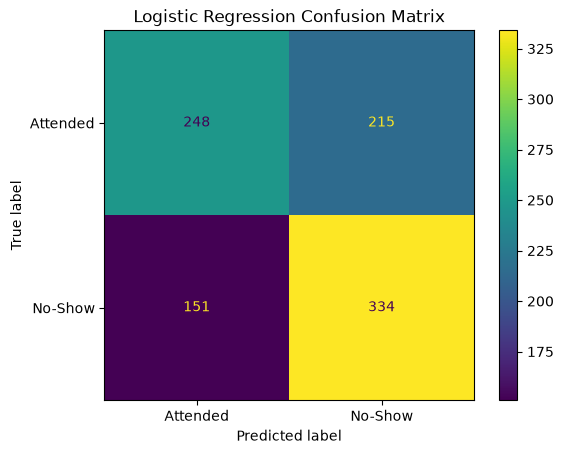

In [200]:
from sklearn.metrics import ConfusionMatrixDisplay 

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Attended", "No-Show"]).plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

The confusion matrix for the Logistic Regression baseline model is:

- True Negative (TN): 248 — The model correctly predicted 248 appointments as attended (0).
- False Positive (FP): 215 — The model predicted 215 appointments as no-shows (1), but they were actually attended (0).
- False Negative (FN): 151 — The model predicted 151 appointments as attended (0), but they were actually no-shows (1).
- True Positive (TP): 334 — The model correctly predicted 334 appointments as no-shows (1).

The model correctly classified 582 appointments (248 true negatives + 334 true positives) and incorrectly classified 366 appointments (215 false positives + 151 false negatives).

For this project, the 151 false negatives are particularly important because they represent actual no-show appointments that the model failed to identify and instead classified as attended. These cases represent missed opportunities to identify patients who may have benefited from preventive interventions, such as reminders or follow-up communication.

The 334 true positives show that the model was able to correctly identify a substantial number of patients who missed their appointments. However, the 215 false positives indicate that the model also incorrectly classified a considerable number of patients who actually attended their appointments as no-shows.

Overall, the confusion matrix shows that the baseline Logistic Regression model has a reasonable ability to identify no-show appointments, but there is still room for improvement. In particular, reducing the number of false negatives would help the model identify more actual no-show appointments, while reducing false positives would help avoid unnecessary interventions for patients who are likely to attend.

### 14.6 Receiver operating characteristic (ROC) curve and area under the curve (AUC)

The ROC-AUC evaluation will be used to assess how well the Logistic Regression baseline model distinguishes between the two appointment outcomes: attended and no-show.

The ROC evaluates the model's ability to distinguish between attended and no-show appointments across different classification thresholds. It compares the True Positive Rate (TPR) against the False Positive Rate (FPR) at different probability thresholds.

The AUC provides a single numerical measure of the model's overall ability to distinguish between the two classes. An AUC value closer to 1.0 indicates better discrimination between attended and no-show appointments, while a value closer to 0.5 indicates that the model has little ability to distinguish between the two classes.

The ROC-AUC evaluation will therefore provide an additional assessment of the Logistic Regression baseline model beyond accuracy, precision, recall, and F1-score. It will help determine how effectively the model separates patients who are likely to attend their appointments from those who are likely to miss them.

In [201]:
#Getting the predicted probabilities for the no-show class (1)

y_pred_proba = logistic_model.predict_proba(X_test)[:, 1]

print("First 10 no-show probabilities:")
print(y_pred_proba[:10])

First 10 no-show probabilities:
[0.37329462 0.37795666 0.68232186 0.48250704 0.52882303 0.5469354
 0.4542519  0.54144993 0.30081833 0.6254046 ]


The expression [:, 1] selects the probability associated with class 1, which is the no-show class.

The resulting y_pred_proba therefore contains the model's estimated probability that each testing appointment will result in a no-show.

In [203]:
#Calculating the ROC-AUC score

roc_auc = roc_auc_score(y_test, y_pred_proba)

print("ROC-AUC:", round(roc_auc, 4))
print("ROC-AUC (%):", round(roc_auc * 100, 2), "%")

ROC-AUC: 0.6642
ROC-AUC (%): 66.42 %


The Logistic Regression baseline model achieved a ROC-AUC score of 0.6642 (66.42%).

The ROC-AUC score measures how well the model distinguishes between the two appointment outcomes across different classification thresholds. In this project, the two classes are Attended (0) and No-Show (1).

An AUC of 0.5 represents a model with no meaningful ability to distinguish between the two classes, while an AUC closer to 1.0 represents stronger discrimination. The obtained AUC of 0.6642 indicates that the baseline Logistic Regression model has a moderate ability to distinguish between attended and no-show appointments.

The ROC-AUC result is consistent with the other evaluation metrics obtained for the baseline model. Although the model demonstrates some ability to differentiate between the two appointment outcomes, its performance is not yet strong enough to provide highly reliable separation between patients who will attend and those who are likely to miss their appointments.

Overall, the ROC-AUC score of 66.42% provides an additional baseline measure of model performance. This result establishes a reference point that can be used to determine whether subsequent model improvements in later stages lead to better discrimination between attended and no-show appointments.

### 14.7 Evaluation summary

The Logistic Regression baseline model was evaluated using multiple performance metrics to obtain a balanced understanding of its ability to predict appointment no-shows. The evaluation included Accuracy, Precision, Recall, F1-Score, ROC-AUC, and the Confusion Matrix.

The results obtained were:

| Evaluation metric | Result |
|---|---:|
| Accuracy | 61.39% |
| Precision | 60.84% |
| Recall | 68.87% |
| F1-Score | 64.60% |
| ROC-AUC | 66.42% |

The confusion matrix was:

| | Predicted Attended | Predicted No-Show |
|---|---:|---:|
| Actual Attended | 248 | 215 |
| Actual No-Show | 151 | 334 |

The baseline model achieved an accuracy of 61.39%, indicating that approximately 61% of the appointments in the test set were classified correctly. However, accuracy alone does not provide a complete assessment of the model because the project is specifically concerned with identifying appointment no-shows.

The model achieved a precision of 60.84% and a recall of 68.87% for the no-show class. The higher recall indicates that the model was able to identify a relatively larger proportion of actual no-show appointments, although some actual no-shows were still missed.

The F1-score of 64.60% provides a combined measure of precision and recall and indicates a moderate balance between the model's ability to identify no-shows and the reliability of its no-show predictions.

The ROC-AUC score of 66.42% further indicates that the model has a moderate ability to distinguish between attended and no-show appointments across different probability thresholds.

The confusion matrix provides additional insight into the model's errors. The model correctly identified 334 actual no-show appointments, while 151 actual no-show appointments were incorrectly predicted as attended. These false negatives are important because they represent missed opportunities to identify patients who may benefit from preventive interventions such as appointment reminders or follow-up communication.

At the same time, the model produced 215 false positives, meaning that a substantial number of patients who actually attended their appointments were incorrectly classified as no-shows. This suggests that improving the model should involve not only increasing its ability to detect no-shows but also reducing unnecessary predictions of no-shows.

Overall, the Logistic Regression model provides a useful baseline level of performance for the appointment no-show prediction problem. Its results indicate that there is a meaningful relationship between the available features and appointment attendance behaviour, but the model's predictive performance is still moderate. These results establish a baseline against which more advanced modelling approaches and improvements can be evaluated in subsequent stages of the project.

## 15. Interpretation of results

The evaluation results provide an overall understanding of how well the Logistic Regression baseline model predicts appointment no-shows. However, model performance metrics alone do not fully explain the practical meaning of the results.

This section interprets the model's performance in the context of the healthcare appointment no-show prediction problem. The interpretation focuses on the model's predictive performance, important patterns identified during the analysis, potential implications for healthcare operations, and the consequences of incorrect predictions.

The interpretation will consider both the strengths and weaknesses of the baseline model. Particular attention will be given to the model's ability to identify actual no-show appointments, as well as the false positive and false negative predictions identified through the confusion matrix.

The purpose of this section is to connect the technical modelling results with the underlying business and healthcare problem and to identify areas where the model could be improved in later stages of the project.

### 15.1 Model performance

The Logistic Regression baseline model demonstrated a moderate level of predictive performance in identifying appointment no-shows.

The model achieved an accuracy of 61.39%, meaning that it correctly classified approximately 61% of appointments in the test set. However, accuracy alone does not fully describe the model's effectiveness because the primary objective of this project is to identify appointments that are likely to result in a no-show.

For the no-show class, the model achieved a precision of 60.84%. This means that when the model predicted an appointment as a no-show, approximately 61% of those predictions were actually no-shows. The remaining predictions were appointments that were predicted as no-shows but were actually attended.

The model achieved a recall of 68.87%, which was higher than its precision. This indicates that the model was able to identify a relatively large proportion of the appointments that actually resulted in no-shows. However, approximately 31% of actual no-show appointments were still missed by the model.

The F1-score of 64.60% indicates a moderate balance between precision and recall. This suggests that the baseline model provides a reasonable starting point but still has considerable potential for improvement.

The ROC-AUC score of 66.42% also indicates moderate discriminatory ability. The model can distinguish between attended and no-show appointments to some extent, but it does not provide a strong separation between the two outcomes.

Overall, the baseline Logistic Regression model demonstrates that the available appointment-related features contain useful information for predicting no-shows. However, the moderate performance across the evaluation metrics indicates that the model is not yet sufficiently reliable for highly accurate prediction. The results therefore provide a useful baseline against which improved models and additional feature engineering can be compared in later stages of the project.

### 15.2 Important predictive patterns

The exploratory analysis identified several patterns that may contribute to the model's predictions.

The strongest observed patterns included:

- Longer booking lead times were associated with higher no-show counts.
- Previous no-show history was associated with a higher likelihood of a current no-show.
- Greater distance from the clinic was associated with relatively higher no-show levels.
- Appointment type, appointment timing and demographic characteristics showed more moderate differences between attended and no-show appointments.

These findings are based primarily on exploratory analysis and should not be interpreted as formal measures of model feature importance.

A future modelling stage could examine model coefficients, permutation importance or other feature-importance techniques to determine which predictors contribute most strongly to model predictions.

### 15.3 Business interpretation

Appointment no-shows can have practical consequences for healthcare facilities because an appointment that is not attended may result in unused clinical capacity, inefficient scheduling, and delays in providing services to patients who require care.

The Logistic Regression baseline model provides an initial approach for identifying appointments that may be at higher risk of becoming no-shows. With a recall of 68.87%, the model was able to identify a relatively large proportion of the appointments that actually resulted in no-shows.

From a healthcare operations perspective, these predictions could potentially be used to support targeted interventions. For example, patients predicted to have a higher probability of missing an appointment could receive additional appointment reminders, confirmation messages, or follow-up communication before their scheduled appointment.

However, the model's precision of 60.84% and the presence of 215 false positives indicate that not every appointment predicted as a no-show would actually be missed. Therefore, using the model to automatically intervene with every predicted no-show could result in unnecessary communication or inefficient use of healthcare resources.

The 151 false negatives are also important from a business perspective. These represent appointments that actually became no-shows but were predicted as attended. Such cases would not be identified by the model for preventive intervention, meaning that opportunities to reduce avoidable no-shows could be missed.

Therefore, the baseline model should be viewed as a decision-support tool rather than a replacement for healthcare staff judgement. Its predictions could be used alongside existing appointment management processes to help prioritise which patients may require additional attention.

Overall, the results suggest that predictive modelling has potential to support more proactive appointment management. However, the moderate performance of the baseline model indicates that further model improvement and validation would be necessary before considering its use in a real healthcare environment.

### 15.4 Model errors and their implications

The confusion matrix provides important information about the types of errors made by the Logistic Regression baseline model.

The model produced 215 false positives and 151 false negatives.

The 215 false positives represent appointments that were actually attended but were incorrectly predicted as no-shows. From a healthcare operational perspective, these errors could result in unnecessary interventions, such as sending additional reminders or follow-up communication to patients who were already likely to attend. If such predictions were used at scale, they could lead to inefficient use of staff time and communication resources.

The 151 false negatives represent appointments that actually resulted in no-shows but were incorrectly predicted as attended. These errors are particularly important for this project because they represent actual no-show appointments that the model failed to identify. Consequently, these patients would not be prioritised for a potential preventive intervention based on the model's prediction.

The model also correctly identified 334 actual no-show appointments, demonstrating that the baseline model can successfully detect a substantial number of no-show cases. In addition, it correctly classified 248 appointments as attended.

The presence of both false positives and false negatives demonstrates the trade-off involved in predicting appointment no-shows. Increasing the model's ability to identify no-shows may result in more false positives, while attempting to reduce false positives may cause more actual no-shows to be missed.

Therefore, future model development should consider the practical consequences of both types of errors rather than focusing only on overall accuracy. In the context of appointment management, the relative cost of missing a potential no-show compared with unnecessarily contacting a patient should be considered when selecting an appropriate classification threshold.

Overall, analysing these errors provides a more realistic understanding of the baseline model's limitations and helps identify areas that should be addressed during future model improvement.

## 16. Cross-Track collaboration

The HealthConnect project involves different areas of work that contribute to the development of a practical healthcare solution. Cross-track collaboration is therefore important because the data science process needs to remain aligned with the healthcare problem and the intended use of the prediction model.

Collaboration provides an opportunity to exchange information about the healthcare problem, available data, project requirements, and the practical implications of predicting appointment no-shows.

In this project, the data science work focused on preparing the appointment dataset, identifying relevant predictors, developing a baseline classification model, and evaluating its ability to identify potential no-show appointments.

The collaboration process helped ensure that the analytical approach remained connected to the broader project objective rather than treating the machine learning model as an isolated technical exercise.

### 16.1 Collaboration point

The main collaboration point was between the Data Analytics and Data Science tracks, where analytical findings from the appointment dataset could inform the development of the no-show prediction model.

The analysis identified several patterns that were relevant to the modelling task. In particular, booking lead time, previous no-show history, and distance to the clinic showed observable relationships with appointment no-show behaviour.

These findings helped guide the Data Science process by identifying variables that warranted further investigation and by supporting the development of engineered features such as booking lead-time groups and distance groups.

### 16.2 Information exchanged

The information exchanged during the collaboration focused on the healthcare problem, the available appointment data, the requirements of the prediction task, and the practical use of the resulting model.

From the data science perspective, important information included the definition of the appointment no-show outcome, the variables available in the dataset, and the distinction between information that would be available before an appointment and information that would only become available afterwards.

The analysis also highlighted the importance of avoiding data leakage. Variables such as waiting time and appointment outcome were therefore not used as predictors because they would not be available at the time when a no-show prediction would need to be made.

The data science work also provided information about the observed patterns in the dataset. In particular, booking lead time, previous no-show history, and distance to the clinic showed useful associations with appointment attendance. These findings helped identify variables that could potentially contribute to predicting appointments at higher risk of no-show.

The collaboration therefore involved exchanging information about both the technical characteristics of the dataset and the practical requirements of using predictions to support appointment management.

### 16.3 Impact on Data Science work

The cross-track dependency helped connect exploratory data analysis with the machine learning workflow.

The analytical findings influenced the Data Science process by supporting decisions about feature selection and feature engineering. For example, booking lead time and distance to the clinic were converted into grouped features so that different ranges could be examined as potential predictors rather than relying only on their raw numerical values.

The collaboration also reinforced the importance of interpreting model development within the broader HealthConnect problem. Rather than selecting variables only for technical reasons, the modelling process considered whether the variables were meaningful, available before the appointment, and appropriate for predicting potential no-shows.

Overall, the Data Analytics dependency supported the transition from understanding the data to developing and evaluating the baseline Data Science model.

## 17. Modelling limitations

Although the Logistic Regression baseline model provided useful initial results, several limitations should be considered when interpreting its performance and potential application to healthcare appointment no-show prediction.

The model was developed using the available dataset, the selected features, and the preprocessing and modelling approach applied during this project. Therefore, its performance is dependent on the quality, completeness, representativeness, and relevance of the available data.

The evaluation results indicate that the baseline model has moderate predictive performance, with an accuracy of 61.39%, precision of 60.84%, recall of 68.87%, F1-score of 64.60%, and ROC-AUC of 66.42%. These results show that the model has useful predictive ability, but there is still considerable room for improvement.

It is therefore important to recognise the limitations of the dataset, the available variables, and the modelling approach before drawing conclusions about the model's effectiveness or considering its application in a real healthcare environment.

The following subsections discuss the main limitations related to the dataset, data quality, modelling approach, and the ability of the model to generalise to other healthcare settings.

### 17.1 Dataset limitations

The dataset used for this project provides useful information for investigating appointment no-show behaviour; however, several limitations should be considered when interpreting the modelling results.

First, the dataset represents a specific set of healthcare appointments and may not fully represent appointment behaviour across different healthcare facilities, regions, patient populations, or healthcare systems. Differences in healthcare access, appointment-management procedures, patient demographics, and operational practices may influence no-show behaviour.

Second, the available variables may not capture all of the factors that influence whether a patient attends or misses an appointment. Factors such as transportation difficulties, changes in personal circumstances, work commitments, communication barriers, socioeconomic conditions, or other external circumstances may not be fully represented in the dataset.

Third, the target variable describes whether an appointment was attended or resulted in a no-show, but the dataset does not necessarily explain the underlying reason for a patient's absence. As a result, the model can identify patterns associated with no-shows but cannot determine why a particular patient missed an appointment.

These limitations may restrict the amount of information available to the model and therefore contribute to the moderate predictive performance observed during evaluation.

The dataset should therefore be viewed as a useful foundation for developing and evaluating a baseline predictive model, while recognising that additional and more representative information may be required to develop a more robust model for practical healthcare applications.

### 17.2 Data limitations

The quality and availability of the input variables can directly affect the performance of a predictive model. Although the data preparation process addressed the identified data quality issues, the information available in the dataset may still limit the model's ability to accurately predict appointment no-shows.

One limitation is that the available features may not contain sufficient information to explain all of the factors associated with appointment attendance behaviour. Important contextual factors may be absent from the dataset, meaning that the model must make predictions using only the information provided by the available variables.

Another limitation is that some relationships between the variables and appointment outcomes may be complex or non-linear. A simple Logistic Regression model may not be able to capture all such relationships because it primarily models the relationship between the predictors and the log-odds of the outcome.

The data may also contain natural variation in patient behaviour that cannot be completely explained by the recorded features. Patients with similar recorded characteristics may still have different appointment outcomes because of circumstances that are not captured in the dataset.

In addition, the available data represents historical appointment behaviour. Patterns observed in historical data may change over time as patient behaviour, healthcare services, appointment systems, and operational practices change. This means that model performance should be monitored if the model is eventually applied to new data.

These data limitations may contribute to the moderate performance observed for the baseline model and highlight the potential value of collecting additional relevant variables and improving feature representation in future stages of the project.

### 17.3 Modelling limitations

The Logistic Regression model was selected as the baseline classification algorithm because it provides a relatively simple, interpretable, and appropriate starting point for a binary prediction problem. However, the choice of modelling approach introduces several limitations that should be considered when interpreting the results.

One limitation is that Logistic Regression assumes a linear relationship between the input features and the log-odds of the outcome. Appointment no-show behaviour may involve more complex relationships that cannot be adequately represented by this assumption. For example, the effect of one feature may depend on the value of another feature, resulting in interactions that a basic Logistic Regression model may not capture automatically.

Another limitation is that the baseline model may not capture complex non-linear patterns in the data. More flexible machine learning algorithms, such as Decision Trees, Random Forests, Gradient Boosting methods, or other ensemble models, may be able to identify relationships that are not easily represented by Logistic Regression.

The model's performance is also influenced by the selected classification threshold. The default threshold used for classification determines whether a predicted probability is converted into an Attended (0) or No-Show (1) prediction. Changing this threshold could affect the balance between false positives and false negatives. This is particularly important in this project because missing an actual no-show and unnecessarily identifying an attending patient may have different operational consequences.

In addition, the baseline model was evaluated using a single modelling approach rather than a broad comparison of different algorithms. Therefore, the current results provide a baseline for comparison rather than evidence that Logistic Regression is the most suitable model for the problem.

The moderate ROC-AUC score of 66.42% indicates that the model has some ability to distinguish between attended and no-show appointments, but its discriminatory performance is not yet strong. This suggests that alternative algorithms, improved feature engineering, hyperparameter tuning, and threshold optimisation may provide opportunities for improving predictive performance in later stages.

Therefore, the Logistic Regression model should be regarded as a baseline model for establishing an initial performance benchmark, rather than as the final predictive solution for appointment no-show prediction.

### 17.4 Generalisation considerations

Generalisation refers to the ability of a machine learning model to maintain useful predictive performance when it is applied to new, previously unseen data. This is an important consideration for the appointment no-show prediction problem because a model that performs reasonably well on the current test data may not necessarily perform at the same level when applied to different appointments or healthcare environments.

The Logistic Regression model was trained and evaluated using data from the available dataset. Although the dataset was divided into training and testing subsets to evaluate the model on unseen observations, the test set still comes from the same overall dataset. Therefore, the evaluation provides an indication of how the model performs on similar data, but it does not guarantee the same performance on data collected from a different healthcare facility or patient population.

Differences between healthcare facilities may affect the model's generalisation. For example, appointment scheduling procedures, reminder systems, patient demographics, healthcare accessibility, and administrative practices may differ between facilities. These differences could change the patterns associated with appointment attendance and no-show behaviour.

Patient behaviour may also change over time. Factors influencing appointment attendance in the historical dataset may not remain the same in the future. Changes in healthcare services, communication methods, appointment systems, or patient circumstances could therefore affect the model's predictive performance.

The moderate ROC-AUC score of 66.42% obtained by the baseline model should consequently be interpreted as performance on the current modelling dataset rather than as a guaranteed level of performance in a real-world healthcare environment.

Before practical deployment, the model would require additional validation using new and independent data. Cross-validation, testing on data from different time periods, and, where possible, evaluation using data from other healthcare facilities could provide stronger evidence of whether the model generalises effectively.

Therefore, the current Logistic Regression model should be considered a baseline predictive model whose generalisation ability has not yet been fully established. Future stages of the project should investigate model validation and robustness on additional data before any real-world implementation is considered.

## 18. Recommendations for Week 6

The Week 5 modelling process established a baseline Logistic Regression model for predicting healthcare appointment no-shows and provided an initial assessment of its predictive performance. The evaluation results showed that the model has moderate predictive ability, with an accuracy of 61.39%, precision of 60.84%, recall of 68.87%, F1-score of 64.60%, and ROC-AUC of 66.42%.

Although these results demonstrate that the available data contains useful information for predicting appointment outcomes, the model can be further improved. The limitations identified in the previous section also indicate several areas that should be investigated before considering the model suitable for practical application.

The recommendations for Week 6 therefore focus on improving model performance, investigating the data and predictive patterns in greater depth, and considering how the model could eventually be developed into a more robust decision support solution.

The following subsections outline the recommended areas of work for the next stage of the project.

### 18.1 Model improvement

The first priority for Week 6 should be to improve the predictive performance of the baseline Logistic Regression model while maintaining a clear and reproducible modelling process.

One important area for improvement is feature engineering. Additional useful features can be created from the existing variables to better represent appointment timing, patient history, scheduling patterns, and other relevant relationships within the data. Carefully engineered features may provide the model with more informative inputs for distinguishing between attended and no-show appointments.

The next stage should also investigate alternative classification algorithms. Models such as Decision Trees, Random Forests, and Gradient Boosting can be compared with the Logistic Regression baseline to determine whether more flexible algorithms can capture relationships that the baseline model may not adequately represent.

Hyperparameter tuning should also be considered for the selected models. Appropriate model parameters can be systematically tested to determine whether predictive performance can be improved without unnecessarily increasing model complexity.

Another important area is classification threshold optimisation. The baseline model uses a default probability threshold to convert predicted probabilities into the final classes of Attended (0) and No-Show (1). Since identifying actual no-show appointments is an important objective of this project, different thresholds can be investigated to determine whether recall can be improved while maintaining an acceptable level of precision.

Model improvement should not be based on accuracy alone. Future models should continue to be evaluated using precision, recall, F1-score, ROC-AUC, and the confusion matrix. Particular attention should be given to the balance between false positives and false negatives because both types of errors have practical implications for appointment management interventions.

Finally, any improved model should be compared directly with the Week 5 Logistic Regression baseline. This will make it possible to determine whether the additional modelling techniques provide a meaningful improvement over the established baseline.

Overall, Week 6 should focus on developing a more effective and robust predictive model while maintaining the interpretability, reproducibility, and evaluation principles established during Week 5.

### 18.2 Further analysis

In addition to improving the predictive model, Week 6 should include further analysis of the relationships between the available features and appointment outcomes. A deeper analysis can help identify patterns that may not have been fully explored during the initial exploratory data analysis.

One area for further investigation is the relationship between appointment timing and no-show behaviour. Variables related to the scheduling of appointments can be analysed in greater detail to determine whether the time between scheduling and the appointment date is associated with an increased likelihood of a no-show.

Further analysis should also investigate the effect of patient appointment history where suitable historical information is available. Previous attendance and no-show behaviour may provide valuable information about future appointment attendance patterns.

The relationships between important categorical variables and the target outcome should also be examined in greater depth. This can help identify whether certain groups or appointment characteristics demonstrate consistently different no-show patterns within the dataset.

Additional analysis of feature interactions should also be considered. Two variables may have limited predictive value individually but may provide more useful information when considered together. Investigating such relationships may help identify patterns that a simple baseline analysis does not reveal.

Where appropriate, statistical analysis can be used to determine whether observed differences between groups are statistically meaningful rather than simply the result of random variation in the sample.

Finally, feature importance and model coefficients should be examined for the improved models. Understanding which variables contribute most strongly to the predictions will help connect the modelling results with the underlying healthcare appointment problem and improve the interpretability of the final solution.

Overall, further analysis in Week 6 should aim to strengthen the understanding of appointment no-show behaviour, identify potentially useful predictive patterns, and provide evidence to guide subsequent feature engineering and model development.

### 18.3 Future development

Beyond the immediate model improvements planned for Week 6, the appointment no-show prediction project could be developed further into a more robust and practical decision support solution.

One potential area for future development is the integration of the predictive model into an appointment management workflow. A model could potentially generate a no-show risk score for upcoming appointments, allowing healthcare staff to identify higher risk appointments before the scheduled date.

The model could also be combined with an automated or semi-automated reminder system. Patients identified as having a higher predicted probability of missing an appointment could receive appropriate reminders or confirmation requests. This could help healthcare facilities use their available communication resources more efficiently.

Another important area for future development is continuous model validation and monitoring. Once a model is applied to new data, its performance should be monitored over time to determine whether prediction quality remains stable. Changes in patient behaviour, healthcare processes, or appointment management systems could result in changes in the patterns learned by the model.

Future development should also consider model fairness and responsible use. Predictions should be evaluated across relevant patient groups to identify whether the model performs consistently and whether certain groups may be disproportionately affected by prediction errors. The model should support healthcare decision-making rather than be used as the sole basis for decisions affecting patients.

Additional data could also be incorporated in future versions of the project. Relevant information about appointment history, communication outcomes, scheduling characteristics, or other operational factors may improve the model's ability to identify no-show risk.

Finally, the project could be extended into a complete end-to-end data science solution that includes data collection, preprocessing, exploratory analysis, model development, validation, deployment, monitoring, and periodic model retraining.

Overall, future development should focus not only on achieving higher predictive performance but also on ensuring that the resulting solution is reliable, interpretable, responsible, and useful within a real healthcare appointment-management environment.

## 19. Week 5 project summary

Week 5 focused on developing, evaluating, and interpreting a baseline machine learning model for predicting healthcare appointment no-shows. The work progressed from the prepared dataset and selected features to model training, performance evaluation, interpretation of results, collaboration, identification of limitations, and recommendations for future development.

A Logistic Regression model was developed as the baseline classification model because it provides a suitable and interpretable starting point for a binary classification problem. The target variable was defined as 0 = Attended and 1 = No-Show.

The model was evaluated using multiple performance measures, including Accuracy, Precision, Recall, F1-Score, ROC-AUC, and the Confusion Matrix. These evaluation techniques provided a broader understanding of the model's predictive ability rather than relying on a single performance metric.

The results showed that the baseline model achieved moderate predictive performance. The findings were then interpreted in the context of the healthcare appointment no-show problem, with particular attention given to the identification of actual no-show appointments and the practical implications of false positive and false negative predictions.

The Week 5 work also included consideration of cross-track collaboration, modelling limitations, dataset limitations, data limitations, and generalisation considerations. These activities helped establish a realistic understanding of what the current model can and cannot achieve.

Finally, recommendations were developed for Week 6, focusing on model improvement, further analysis, feature engineering, alternative algorithms, threshold optimisation, validation, and possible future development of the solution.

The following subsections summarise the work completed, key findings, challenges encountered, important modelling decisions, and the remaining work required for the next stage of the project.

### 19.1 Work completed

The main objective for Week 5 was to move the HealthConnect Data Science work from the planning stage established in Week 4 into practical implementation.

The following activities were completed:

- Reviewed and refined the Week 4 machine-learning problem definition.
- Defined the appointment-level no-show prediction problem.
- Prepared the HealthConnect appointment dataset for modelling.
- Assessed missing values, duplicates, categorical consistency and numerical ranges.
- Excluded cancelled appointments from the binary no-show modelling population.
- Defined the target variable as 0 = Attended and 1 = No-Show.
- Assessed potential data leakage and excluded inappropriate variables.
- Conducted exploratory data analysis.
- Examined numerical and categorical feature distributions.
- Analysed relationships between predictors and the no-show target.
- Conducted correlation analysis.
- Created booking lead-time and distance groups as engineered features.
- Selected 12 candidate predictors for baseline modelling.
- Applied an 80:20 stratified train/test split.
- Developed a Logistic Regression baseline using a preprocessing pipeline.
- Generated predictions for the unseen testing dataset.
- Evaluated the model using accuracy, precision, recall, F1-score, confusion matrix and ROC-AUC.
- Interpreted the initial model results.
- Documented cross-track collaboration considerations.
- Identified modelling limitations and recommendations for Week 6.

### 19.2 Key Findings

The exploratory analysis identified several useful patterns in the appointment data.

The strongest observed patterns included the relationship between longer booking lead times and higher no-show counts, the association between previous no-show history and current no-show behaviour, and relatively higher no-show levels among some of the more distant appointment groups.

The target variable was relatively balanced, with 51.15% no-show appointments and 48.85% attended appointments.

The Logistic Regression baseline achieved:

- Accuracy: 61.39%
- Precision: 60.84%
- Recall: 68.87%
- F1-score: 64.60%
- ROC-AUC: 66.42%

The results indicate that the dataset contains useful predictive information, particularly for identifying a proportion of actual no-show appointments. However, the model still produces both false-positive and false-negative predictions and therefore requires further improvement and validation.

### 19.3 Challenges

Several challenges were encountered during the Week 5 implementation.

One challenge was determining which variables could safely be used as predictors without introducing data leakage. This required considering whether each variable would actually be available at the intended pre-appointment prediction point.

Another challenge involved deciding how to represent variables such as booking lead time and distance. The EDA showed that relationships with no-show behaviour were not necessarily strictly linear, which motivated the creation of grouped representations.

The model evaluation stage also highlighted the importance of using multiple metrics rather than relying only on accuracy. In particular, recall was important because the practical objective involves identifying appointments that may become no-shows.

The modelling process also required careful handling of categorical variables and numerical scaling, which was addressed through a Scikit-learn preprocessing pipeline.

### 19.4 Important decisions

Several important decisions were made during Week 5.

Cancelled appointments were excluded because cancellation represents a different outcome from a scheduled appointment that was not attended.

Outcome-related and potentially unavailable variables were excluded to reduce the risk of data leakage.

The original numerical booking lead-time and distance variables were retained while grouped versions were created to represent broader patterns identified during EDA.

An 80:20 stratified train/test split was selected to provide a held-out testing dataset while maintaining similar class proportions.

Logistic Regression was selected as the baseline model because it provides a simple and interpretable starting point for a binary classification problem.

Model performance was assessed using multiple metrics because no single metric fully describes the usefulness of a no-show prediction model.

### 19.5 Remaining Work

The Week 5 baseline does not represent the completed HealthConnect machine learning solution.

Remaining work includes:

- Comparing additional machine learning algorithms.
- Performing cross-validation and hyperparameter tuning.
- Investigating model interpretability and predictor contribution.
- Evaluating alternative classification thresholds.
- Further validating the engineered features.
- Assessing whether model performance improves using alternative feature representations.
- Considering how predictions could be incorporated into a practical appointment management workflow.
- Evaluating model reliability and generalisation before any potential operational use.

These activities form the basis for the proposed Week 6 work.

## 20. Conclusion

The Week 5 Data Science work successfully moved the HealthConnect appointment no-show project from the planning stage established in Week 4 into practical implementation.

The HealthConnect appointment dataset was prepared and assessed for missing values, duplicates, categorical consistency, numerical validity and potential data leakage. Cancelled appointments were excluded from the modelling population, and the target variable was defined as 0 = Attended and 1 = No-Show.

Exploratory analysis identified several potentially useful patterns. In particular, longer booking lead times, previous no-show history and greater distance from the clinic were associated with higher levels of no-show behaviour. These observations informed the feature-engineering and feature-selection decisions.

Two engineered features, booking_lead_group and distance_group, were created and validated successfully. A total of 12 candidate predictors were then prepared for baseline modelling.

The dataset was divided using an 80:20 stratified train/test split. A Logistic Regression model was developed within a preprocessing pipeline that standardised numerical variables and one-hot encoded categorical variables. This approach ensured that preprocessing was performed consistently while reducing the risk of information leakage from the testing data.

On the unseen testing dataset, the baseline model achieved an accuracy of 61.39%, precision of 60.84%, recall of 68.87%, F1-score of 64.60% and ROC-AUC of 66.42%.

The results indicate that the available appointment information contains some predictive signal for identifying no-show appointments. The relatively higher recall suggests that the baseline model can identify a substantial proportion of actual no-shows, although the model also produces false-positive and false-negative predictions.

The baseline should therefore be viewed as an initial modelling benchmark rather than a final production-ready healthcare solution. Further work is required to compare alternative algorithms, improve predictive performance, validate the model more extensively and investigate how predictions could responsibly support appointment-management processes.

Overall, Week 5 provides a practical and documented foundation for continuing the HealthConnect Data Science work in Week 6. The project has progressed from problem definition and planning to data preparation, exploratory analysis, feature engineering, baseline model development and initial evaluation, while maintaining awareness of data leakage, modelling limitations and the practical healthcare context.